In [ ]:
import torch
import torch.nn.functional as F
from fem_dataset_to_image_full_mesh_diffusion import FemImageDataset as MeshDataset
from fem_model import ScalingVAE5
import json
from torch.utils.data import DataLoader
from utils import EarlyStopping
import gc
import numpy as np
import matplotlib.pyplot as plt


early_stopping = EarlyStopping(
    patience=5,     # FEM/GNN은 15~30 권장
    min_delta=1e-3,  # loss 스케일에 맞게
    mode="min"
)
def collate_flatten(batch): 
    images, conds = [], [] 
    batch_size=len(batch) 
    step_num_in_batch=len(batch[0]["image"]) 
    idxs=[] 
    for i in range(batch_size): 
        idx = torch.randperm(len(batch[0]["image"])) 
        idxs.append(idx) 
        # print(batch[i]['min_max'])
    idxs=np.array(idxs).T 

    for i in range(step_num_in_batch): 
        batch_images=[] 
        batch_conds=[] 
        for b_i,b in enumerate(batch): 
            id=idxs[i][b_i] 
            batch_images.append(b['image'][id]) 
            batch_conds.append(b['cond'][id]) 
        images.append(batch_images) 
        conds.append(batch_conds) 
    return { "image": images, "cond": conds, }

def draw(data1,data1_1,data2,data3,model_param): 
    
    plt.figure(figsize=(8, 4)) 
    plt.subplot(1, 5, 1) 
    plt.imshow(data1.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max()) 
    plt.title("Original Target") 
    plt.axis("off")
    plt.subplot(1, 5, 2) 
    plt.imshow(data1_1.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max()) 
    plt.title("Original Scaled") 
    plt.axis("off") 
    plt.subplot(1, 5, 3) 
    plt.imshow(data2.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max())
    plt.title("Predicted Image") 
    plt.axis("off") 
    plt.subplot(1, 5, 4) 
    plt.imshow(data3.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max())
    plt.title("Predicted Scaled") 
    plt.axis("off")
    plt.subplot(1, 5, 5) 
    plt.imshow(np.abs(data1.cpu().detach().numpy()-data2.cpu().detach().numpy()), cmap="gray")
    plt.title("residual") 
    plt.axis("off")
    plt.tight_layout() 
    plt.show()

def kl_divergence_gaussian(mu, logvar, clamp=(-0.3, 0.3)):
    """
    KL( N(mu, var) || N(0, I) )
    Supports mu/logvar with shape:
      [B, Z] or [B, C, H, W] or [B, ...]
    """
    if clamp is not None:
        logvar = torch.clamp(logvar, min=clamp[0], max=clamp[1])

    # flatten all non-batch dimensions
    mu = mu.view(mu.size(0), -1)
    logvar = logvar.view(logvar.size(0), -1)

    kl = 0.5 * torch.sum(
        torch.exp(logvar) + mu**2 - 1.0 - logvar,
        dim=1
    )

    return kl.mean()

def charbonnier_loss(pred: torch.Tensor,
                     target: torch.Tensor,
                     eps: float = 1e-8,
                     reduction: str = "mean") -> torch.Tensor:
    """
    Charbonnier loss (a smooth L1 / pseudo-Huber variant):
        L = sqrt((pred - target)^2 + eps^2)

    Args:
        pred, target: same shape tensors
        eps: smoothing term (bigger -> more L1-like near 0)
        reduction: "mean" | "sum" | "none"

    Returns:
        loss tensor (scalar if reduced)
    """
    if pred.shape != target.shape:
        raise ValueError(f"Shape mismatch: pred{pred.shape} vs target{target.shape}")

    diff = pred - target
    loss = torch.sqrt(diff * diff + eps * eps)

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    if reduction == "none":
        return loss
    raise ValueError("reduction must be one of {'mean','sum','none'}")




def GradientDifferenceLossCharbonnier( pred, target):
    grad_pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    grad_target_x = target[:, :, :, 1:] - target[:, :, :, :-1]

    grad_pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    grad_target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    return (
        charbonnier_loss(grad_pred_x, grad_target_x) +
        charbonnier_loss(grad_pred_y, grad_target_y)
    )

def cvae_loss(target_x_norm,target,scaled_x_hat, x_hat,mean,std, mu, logvar,epoch, beta=1e-3): 
    recon= charbonnier_loss(target, x_hat)
    recon_2 = GradientDifferenceLossCharbonnier(target,x_hat)
    recon_detail = charbonnier_loss(target_x_norm, scaled_x_hat)
    recon_detail_2 = GradientDifferenceLossCharbonnier(target_x_norm,scaled_x_hat)
    recon_sum=0.8*recon +0.2*recon_2
    recon_detail_sum=0.8*recon_detail +0.2*recon_detail_2
    
    kl = kl_divergence_gaussian(mu, logvar)
    #return (0.8-0.4*epoch/100)*recon_detail +0.05*recon_detail_2+0.1*latent_mean+(0.1+0.4*epoch/100)*latent_logvar+ beta * kl, (recon_detail ,latent_mean,latent_logvar, kl)
    return recon_sum + recon_detail_sum + beta * kl, (recon_sum,recon_detail_sum, kl)

def draw_latent(z): 

    z = z.view(z.size(0), -1) 
    plt.figure(figsize=(8, 4)) 
    plt.hist(z.flatten().detach().cpu(), bins=100) 
    plt.title("Image 1") 
    plt.show()

def train_one_epoch(model, loader, device, opt, model_param,epoch): 
    model.train() 
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            opt.zero_grad() 
            loss.backward() 
            opt.step() 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[TRAIN] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                print('BEFROE TRAIN')
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)
@torch.no_grad()
def eval_one_epoch(model, loader, device,  model_param,epoch):
    model.eval()
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            total += float(loss.item())
            count+=1 
            if count % 20 == 0: 
                print('[VALID] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)

def main():
    root = "./data"
    if torch.cuda.is_available() :
        device='cuda'
    elif torch.backends.mps.is_available() :
        device='mps'
    else :
        device='cpu'

    model_param={ 'in_channels':3, 
                'out_channels':3,
                'GRID':64,
                'loss_scale':1.0,
                'learning_rate':1e-3,
                'num_epochs':1000,
                'base':128,
                'latent_dim':64,
                'batch_size':128,
                'depth':4 } 
    
    train_ds = MeshDataset(root_dir=root,type='train',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 
    val_ds= MeshDataset(root_dir=root,type='valid',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 

    train_loader = DataLoader(train_ds, batch_size=model_param['batch_size'], shuffle=True, collate_fn=collate_flatten) 
    val_loader = DataLoader(val_ds, batch_size=model_param['batch_size'], shuffle=False, collate_fn=collate_flatten) 
    example = train_ds[0] 
    model_param['cond_dim']=len(example['cond'][0]) 
    model_param['dataset_scale_info']=train_ds.scale_info 

    model = ScalingVAE5( in_channels=model_param['in_channels'], 
                latent_dim=model_param['latent_dim'], 
                base=model_param['base'],
                depth=model_param['depth'] ).to(device)
    # ckpt = torch.load("mesh_invariant_diffustion_vae4_4_early_epoch002.pt", map_location=device)
    # model.load_state_dict(ckpt)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=model_param['learning_rate'], weight_decay=1e-6)
    loss_dict={}
    for epoch in range(model_param['num_epochs']):        
        train_loss = train_one_epoch(model, train_loader, device, optimizer,model_param,epoch)
        val_loss = eval_one_epoch(model, val_loader, device,model_param,epoch)
        loss_dict[epoch] = {'train_loss':train_loss, 'val_loss':val_loss}   
        print(f"Epoch {epoch+1}/{model_param['num_epochs']}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}")  
        improved = early_stopping.step(val_loss)
        with open(f"loss_history_diffustion_vae4_3.json", "w", encoding="utf-8") as f:
            json.dump(loss_dict, f, indent=2)
        if improved:
            best_val = val_loss
            # print(eval_one_epoch_sample_mse(model, val_loader, device, sched))
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_early_epoch{str(epoch).zfill(3)}.pt")  # best만 저장

            with open(f"model_param_diffustion_vae4_3_early.json", "w", encoding="utf-8") as f:
                json.dump(model_param, f, indent=2)
        if early_stopping.should_stop:
            print(
                f"\n Early stopping at epoch {epoch} "
                f"(best val = {best_val:.6e})"
            )
            break
        if epoch%5==0:
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_epoch{str(epoch).zfill(3)}.pt")
    torch.save(model.state_dict(), "mesh_invariant_diffustion_vae4_3.pt")
    with open(f"model_param_diffusion_vae4_3.json", "w", encoding="utf-8") as f:
        json.dump(model_param, f, indent=2) 

if __name__ == "__main__":
    main()

100%|██████████| 805/805 [00:05<00:00, 141.11it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...


100%|██████████| 805/805 [00:05<00:00, 151.04it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...
[TRAIN] epoch:  4 batch:  0 step:  50 loss:  0.2460354119539261 recon_detail loss:  (tensor(0.0122, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1962, device='mps:0', grad_fn=<AddBackward0>), tensor(75.1674, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


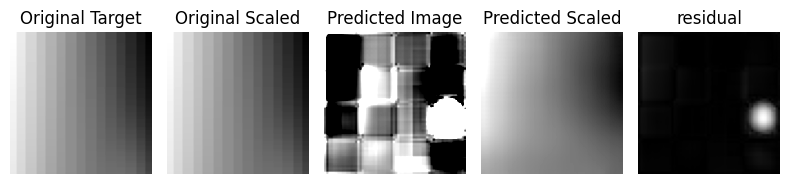

[TRAIN] epoch:  4 batch:  1 step:  100 loss:  0.23236194252967834 recon_detail loss:  (tensor(0.0053, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1912, device='mps:0', grad_fn=<AddBackward0>), tensor(71.6148, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


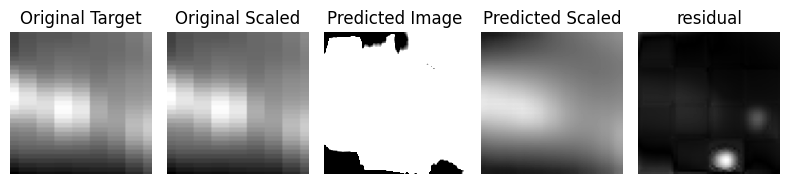

[TRAIN] epoch:  4 batch:  2 step:  150 loss:  0.24699926376342773 recon_detail loss:  (tensor(0.0067, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2057, device='mps:0', grad_fn=<AddBackward0>), tensor(69.1687, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


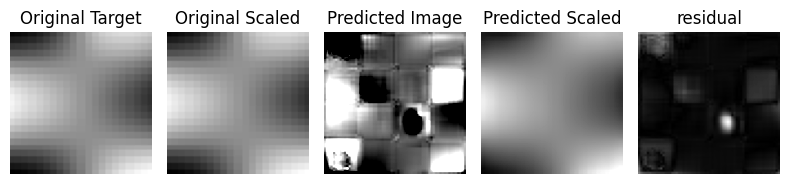

[TRAIN] epoch:  4 batch:  3 step:  200 loss:  0.25140002369880676 recon_detail loss:  (tensor(0.0085, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2071, device='mps:0', grad_fn=<AddBackward0>), tensor(71.5732, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


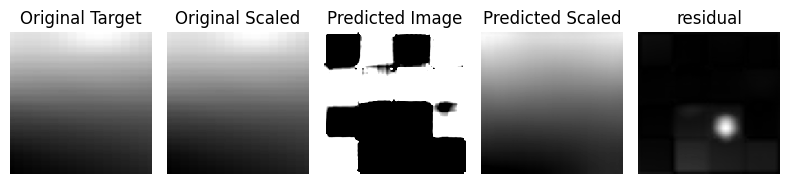

[TRAIN] epoch:  4 batch:  3 step:  250 loss:  0.2160269320011139 recon_detail loss:  (tensor(0.0074, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1748, device='mps:0', grad_fn=<AddBackward0>), tensor(67.6985, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


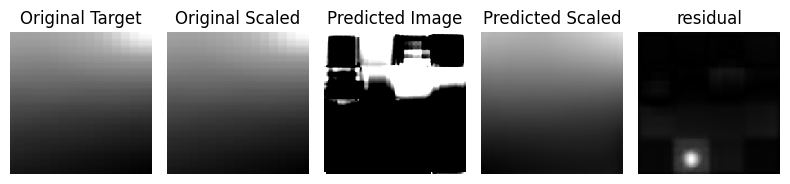

[TRAIN] epoch:  4 batch:  4 step:  300 loss:  0.2328425645828247 recon_detail loss:  (tensor(0.0058, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1903, device='mps:0', grad_fn=<AddBackward0>), tensor(73.5273, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


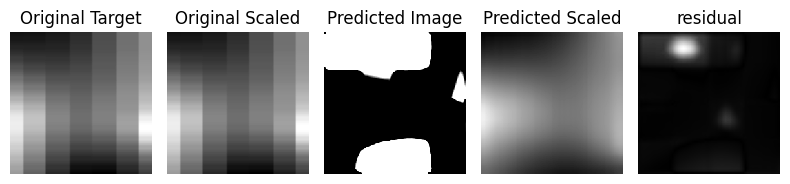

[TRAIN] epoch:  4 batch:  5 step:  350 loss:  0.24207234382629395 recon_detail loss:  (tensor(0.0054, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2024, device='mps:0', grad_fn=<AddBackward0>), tensor(68.4350, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


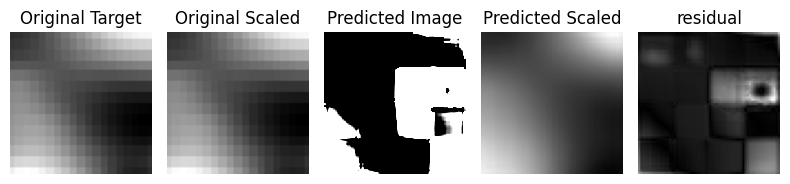

[VALID] epoch:  4 batch:  0 step:  20 loss:  0.2755676507949829 recon_detail loss:  (tensor(0.0069, device='mps:0'), tensor(0.2385, device='mps:0'), tensor(60.3407, device='mps:0'))


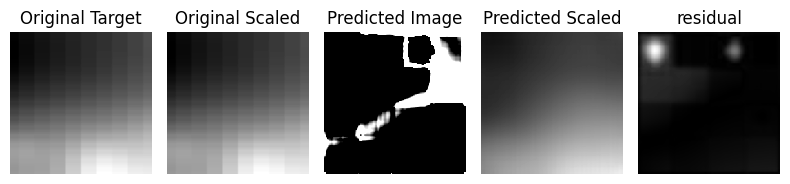

[VALID] epoch:  4 batch:  0 step:  40 loss:  0.2650294303894043 recon_detail loss:  (tensor(0.0069, device='mps:0'), tensor(0.2283, device='mps:0'), tensor(59.6245, device='mps:0'))


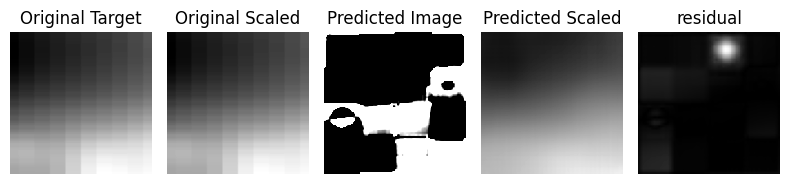

[VALID] epoch:  4 batch:  0 step:  60 loss:  0.25985053181648254 recon_detail loss:  (tensor(0.0068, device='mps:0'), tensor(0.2229, device='mps:0'), tensor(60.2896, device='mps:0'))


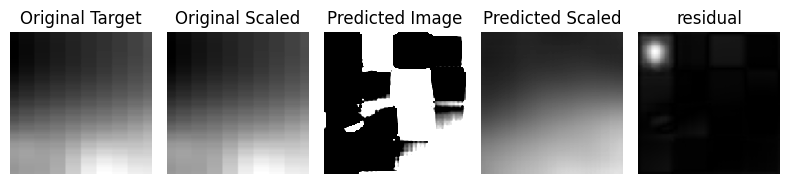

Epoch 5/1000, Train Loss: 2.456796e-01, Val Loss: 2.705434e-01
[TRAIN] epoch:  5 batch:  0 step:  50 loss:  0.2440057247877121 recon_detail loss:  (tensor(0.0055, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1991, device='mps:0', grad_fn=<AddBackward0>), tensor(65.7293, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


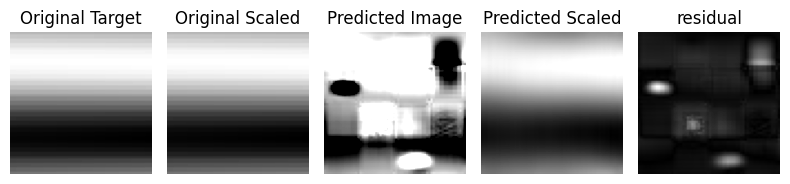

[TRAIN] epoch:  5 batch:  1 step:  100 loss:  0.23456865549087524 recon_detail loss:  (tensor(0.0052, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1907, device='mps:0', grad_fn=<AddBackward0>), tensor(64.3928, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


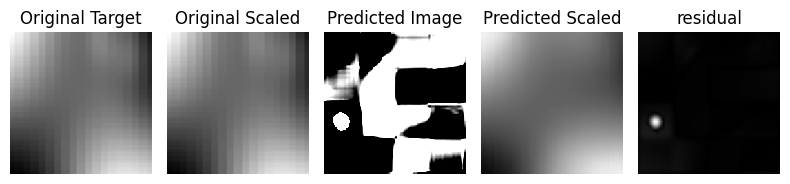

[TRAIN] epoch:  5 batch:  2 step:  150 loss:  0.23792771995067596 recon_detail loss:  (tensor(0.0045, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1941, device='mps:0', grad_fn=<AddBackward0>), tensor(65.4657, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


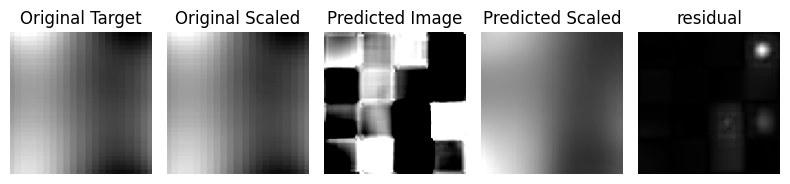

[TRAIN] epoch:  5 batch:  3 step:  200 loss:  0.24765655398368835 recon_detail loss:  (tensor(0.0066, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2032, device='mps:0', grad_fn=<AddBackward0>), tensor(63.0851, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


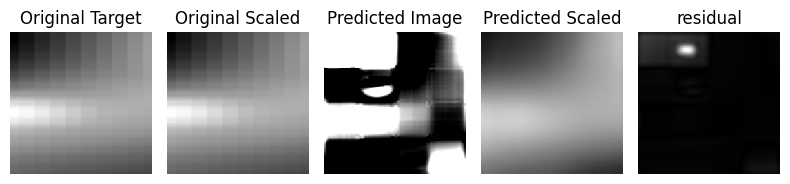

[TRAIN] epoch:  5 batch:  3 step:  250 loss:  0.21132393181324005 recon_detail loss:  (tensor(0.0040, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1702, device='mps:0', grad_fn=<AddBackward0>), tensor(61.9168, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


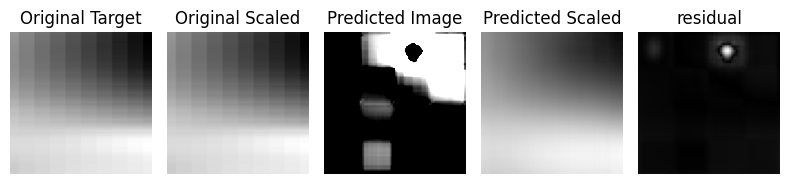

[TRAIN] epoch:  5 batch:  4 step:  300 loss:  0.23033280670642853 recon_detail loss:  (tensor(0.0044, device='mps:0', grad_fn=<AddBackward0>), tensor(0.1878, device='mps:0', grad_fn=<AddBackward0>), tensor(63.6289, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


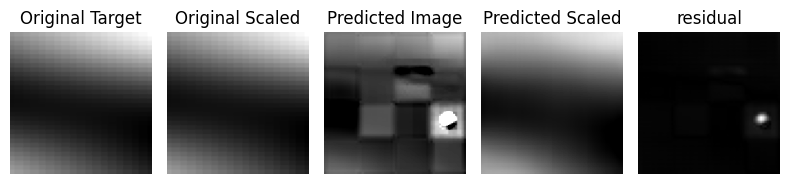

[TRAIN] epoch:  5 batch:  5 step:  350 loss:  0.25440698862075806 recon_detail loss:  (tensor(0.0060, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2110, device='mps:0', grad_fn=<AddBackward0>), tensor(62.3064, device='mps:0', grad_fn=<MeanBackward0>))
BEFROE TRAIN


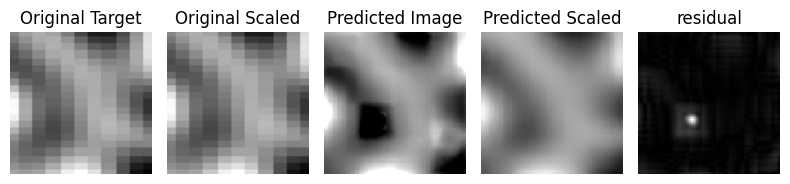

[VALID] epoch:  5 batch:  0 step:  20 loss:  0.3274901509284973 recon_detail loss:  (tensor(0.0045, device='mps:0'), tensor(0.2927, device='mps:0'), tensor(50.4619, device='mps:0'))


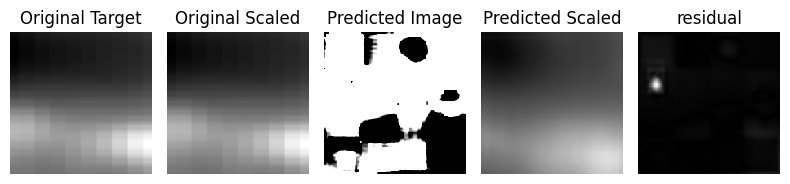

[VALID] epoch:  5 batch:  0 step:  40 loss:  0.33269619941711426 recon_detail loss:  (tensor(0.0044, device='mps:0'), tensor(0.2979, device='mps:0'), tensor(50.6591, device='mps:0'))


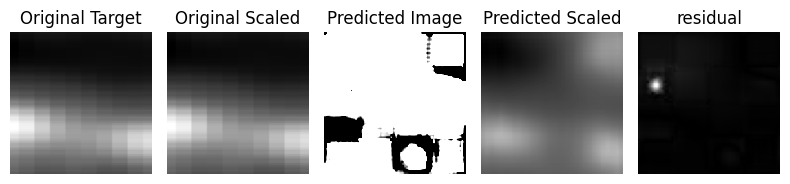

[VALID] epoch:  5 batch:  0 step:  60 loss:  0.34912508726119995 recon_detail loss:  (tensor(0.0046, device='mps:0'), tensor(0.3151, device='mps:0'), tensor(49.0463, device='mps:0'))


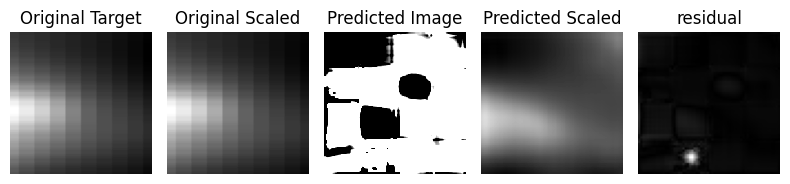

Epoch 6/1000, Train Loss: 2.380767e-01, Val Loss: 3.356604e-01


KeyboardInterrupt: 

In [1]:
import torch
import torch.nn.functional as F
from fem_dataset_to_image_full_mesh_diffusion import FemImageDataset as MeshDataset
from fem_model import ScalingVAE5
import json
from torch.utils.data import DataLoader
from utils import EarlyStopping
import gc
import numpy as np
import matplotlib.pyplot as plt


early_stopping = EarlyStopping(
    patience=5,     # FEM/GNN은 15~30 권장
    min_delta=1e-3,  # loss 스케일에 맞게
    mode="min"
)
def collate_flatten(batch): 
    images, conds = [], [] 
    batch_size=len(batch) 
    step_num_in_batch=len(batch[0]["image"]) 
    idxs=[] 
    for i in range(batch_size): 
        idx = torch.randperm(len(batch[0]["image"])) 
        idxs.append(idx) 
        # print(batch[i]['min_max'])
    idxs=np.array(idxs).T 

    for i in range(step_num_in_batch): 
        batch_images=[] 
        batch_conds=[] 
        for b_i,b in enumerate(batch): 
            id=idxs[i][b_i] 
            batch_images.append(b['image'][id]) 
            batch_conds.append(b['cond'][id]) 
        images.append(batch_images) 
        conds.append(batch_conds) 
    return { "image": images, "cond": conds, }

def draw(data1,data1_1,data2,data3,model_param): 
    
    plt.figure(figsize=(8, 4)) 
    plt.subplot(1, 5, 1) 
    plt.imshow(data1.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max()) 
    plt.title("Original Target") 
    plt.axis("off")
    plt.subplot(1, 5, 2) 
    plt.imshow(data1_1.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max()) 
    plt.title("Original Scaled") 
    plt.axis("off") 
    plt.subplot(1, 5, 3) 
    plt.imshow(data2.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max())
    plt.title("Predicted Image") 
    plt.axis("off") 
    plt.subplot(1, 5, 4) 
    plt.imshow(data3.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max())
    plt.title("Predicted Scaled") 
    plt.axis("off")
    plt.subplot(1, 5, 5) 
    plt.imshow(np.abs(data1.cpu().detach().numpy()-data2.cpu().detach().numpy()), cmap="gray")
    plt.title("residual") 
    plt.axis("off")
    plt.tight_layout() 
    plt.show()

def kl_divergence_gaussian(mu, logvar, clamp=(-0.3, 0.3)):
    """
    KL( N(mu, var) || N(0, I) )
    Supports mu/logvar with shape:
      [B, Z] or [B, C, H, W] or [B, ...]
    """
    if clamp is not None:
        logvar = torch.clamp(logvar, min=clamp[0], max=clamp[1])

    # flatten all non-batch dimensions
    mu = mu.view(mu.size(0), -1)
    logvar = logvar.view(logvar.size(0), -1)

    kl = 0.5 * torch.sum(
        torch.exp(logvar) + mu**2 - 1.0 - logvar,
        dim=1
    )

    return kl.mean()

def charbonnier_loss(pred: torch.Tensor,
                     target: torch.Tensor,
                     eps: float = 1e-8,
                     reduction: str = "mean") -> torch.Tensor:
    """
    Charbonnier loss (a smooth L1 / pseudo-Huber variant):
        L = sqrt((pred - target)^2 + eps^2)

    Args:
        pred, target: same shape tensors
        eps: smoothing term (bigger -> more L1-like near 0)
        reduction: "mean" | "sum" | "none"

    Returns:
        loss tensor (scalar if reduced)
    """
    if pred.shape != target.shape:
        raise ValueError(f"Shape mismatch: pred{pred.shape} vs target{target.shape}")

    diff = pred - target
    loss = torch.sqrt(diff * diff + eps * eps)

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    if reduction == "none":
        return loss
    raise ValueError("reduction must be one of {'mean','sum','none'}")




def GradientDifferenceLossCharbonnier( pred, target):
    grad_pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    grad_target_x = target[:, :, :, 1:] - target[:, :, :, :-1]

    grad_pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    grad_target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    return (
        charbonnier_loss(grad_pred_x, grad_target_x) +
        charbonnier_loss(grad_pred_y, grad_target_y)
    )

def cvae_loss(target_x_norm,target,scaled_x_hat, x_hat,mean,std, mu, logvar,epoch, beta=1e-3): 
    recon= charbonnier_loss(target, x_hat)
    recon_2 = GradientDifferenceLossCharbonnier(target,x_hat)
    recon_detail = charbonnier_loss(target_x_norm, scaled_x_hat)
    recon_detail_2 = GradientDifferenceLossCharbonnier(target_x_norm,scaled_x_hat)
    recon_sum=0.8*recon +0.2*recon_2
    recon_detail_sum=0.8*recon_detail +0.2*recon_detail_2
    
    kl = kl_divergence_gaussian(mu, logvar)
    #return (0.8-0.4*epoch/100)*recon_detail +0.05*recon_detail_2+0.1*latent_mean+(0.1+0.4*epoch/100)*latent_logvar+ beta * kl, (recon_detail ,latent_mean,latent_logvar, kl)
    return recon_sum + recon_detail_sum + beta * kl, (recon_sum,recon_detail_sum, kl)

def draw_latent(z): 

    z = z.view(z.size(0), -1) 
    plt.figure(figsize=(8, 4)) 
    plt.hist(z.flatten().detach().cpu(), bins=100) 
    plt.title("Image 1") 
    plt.show()

def train_one_epoch(model, loader, device, opt, model_param,epoch): 
    model.train() 
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            opt.zero_grad() 
            loss.backward() 
            opt.step() 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[TRAIN] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                print('BEFROE TRAIN')
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)
@torch.no_grad()
def eval_one_epoch(model, loader, device,  model_param,epoch):
    model.eval()
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            total += float(loss.item())
            count+=1 
            if count % 20 == 0: 
                print('[VALID] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)

def main():
    root = "./data"
    if torch.cuda.is_available() :
        device='cuda'
    elif torch.backends.mps.is_available() :
        device='mps'
    else :
        device='cpu'

    model_param={ 'in_channels':3, 
                'out_channels':3,
                'GRID':64,
                'loss_scale':1.0,
                'learning_rate':1e-3,
                'num_epochs':1000,
                'base':128,
                'latent_dim':64,
                'batch_size':128,
                'depth':4 } 
    
    train_ds = MeshDataset(root_dir=root,type='train',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 
    val_ds= MeshDataset(root_dir=root,type='valid',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 

    train_loader = DataLoader(train_ds, batch_size=model_param['batch_size'], shuffle=True, collate_fn=collate_flatten) 
    val_loader = DataLoader(val_ds, batch_size=model_param['batch_size'], shuffle=False, collate_fn=collate_flatten) 
    example = train_ds[0] 
    model_param['cond_dim']=len(example['cond'][0]) 
    model_param['dataset_scale_info']=train_ds.scale_info 

    model = ScalingVAE5( in_channels=model_param['in_channels'], 
                latent_dim=model_param['latent_dim'], 
                base=model_param['base'],
                depth=model_param['depth'] ).to(device)
    ckpt = torch.load("mesh_invariant_diffustion_vae4_3_early_epoch003.pt", map_location=device)
    model.load_state_dict(ckpt)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=model_param['learning_rate'], weight_decay=1e-6)
    loss_dict={}
    for epoch in range(model_param['num_epochs']):  
        epoch=epoch+4      
        train_loss = train_one_epoch(model, train_loader, device, optimizer,model_param,epoch)
        val_loss = eval_one_epoch(model, val_loader, device,model_param,epoch)
        loss_dict[epoch] = {'train_loss':train_loss, 'val_loss':val_loss}   
        print(f"Epoch {epoch+1}/{model_param['num_epochs']}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}")  
        improved = early_stopping.step(val_loss)
        with open(f"loss_history_diffustion_vae4_3.json", "w", encoding="utf-8") as f:
            json.dump(loss_dict, f, indent=2)
        if improved:
            best_val = val_loss
            # print(eval_one_epoch_sample_mse(model, val_loader, device, sched))
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_early_epoch{str(epoch).zfill(3)}.pt")  # best만 저장

            with open(f"model_param_diffustion_vae4_3_early.json", "w", encoding="utf-8") as f:
                json.dump(model_param, f, indent=2)
        if early_stopping.should_stop:
            print(
                f"\n Early stopping at epoch {epoch} "
                f"(best val = {best_val:.6e})"
            )
            break
        if epoch%5==0:
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_epoch{str(epoch).zfill(3)}.pt")
    torch.save(model.state_dict(), "mesh_invariant_diffustion_vae4_3.pt")
    with open(f"model_param_diffusion_vae4_3.json", "w", encoding="utf-8") as f:
        json.dump(model_param, f, indent=2) 

if __name__ == "__main__":
    main()

100%|██████████| 805/805 [00:05<00:00, 136.86it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...


100%|██████████| 805/805 [00:05<00:00, 153.53it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...
[TRAIN] epoch:  6 batch:  0 step:  50 loss:  0.6030922532081604 recon_detail loss:  (tensor(0.0060, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2453, device='mps:0'), tensor(60.9584, device='mps:0'))
BEFROE TRAIN


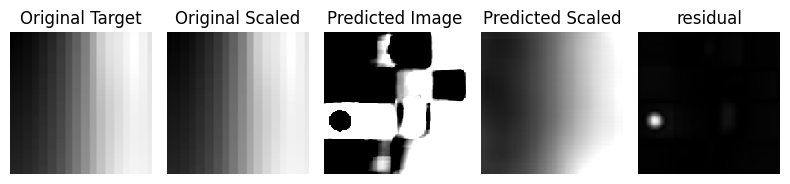

[TRAIN] epoch:  6 batch:  1 step:  100 loss:  0.3138248324394226 recon_detail loss:  (tensor(0.0031, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2432, device='mps:0'), tensor(64.3405, device='mps:0'))
BEFROE TRAIN


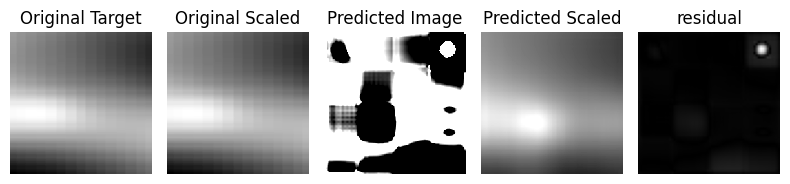

[TRAIN] epoch:  6 batch:  2 step:  150 loss:  0.38917773962020874 recon_detail loss:  (tensor(0.0039, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2207, device='mps:0'), tensor(62.5308, device='mps:0'))
BEFROE TRAIN


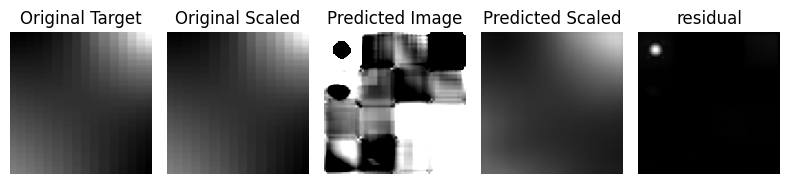

[TRAIN] epoch:  6 batch:  3 step:  200 loss:  0.481129914522171 recon_detail loss:  (tensor(0.0048, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2259, device='mps:0'), tensor(72.4512, device='mps:0'))
BEFROE TRAIN


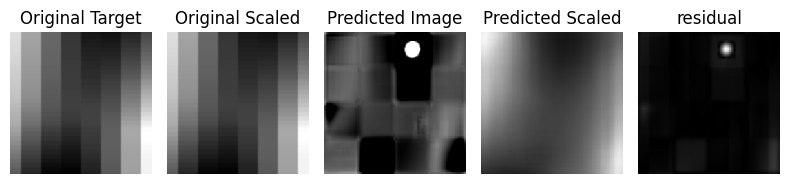

[TRAIN] epoch:  6 batch:  3 step:  250 loss:  0.48033323884010315 recon_detail loss:  (tensor(0.0048, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2265, device='mps:0'), tensor(72.9038, device='mps:0'))
BEFROE TRAIN


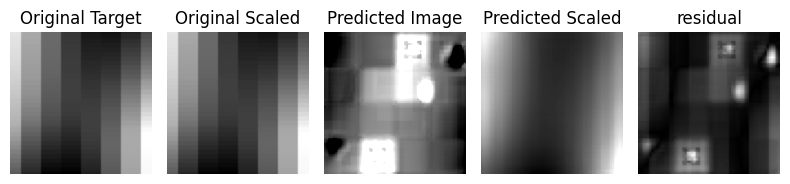

[TRAIN] epoch:  6 batch:  4 step:  300 loss:  0.5824486613273621 recon_detail loss:  (tensor(0.0058, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2558, device='mps:0'), tensor(63.7102, device='mps:0'))
BEFROE TRAIN


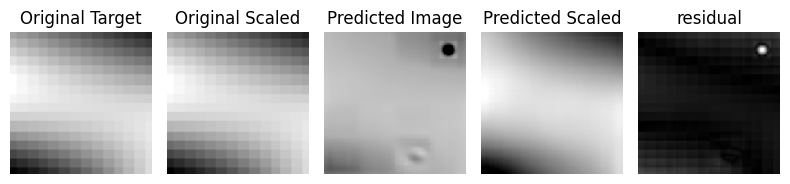

[TRAIN] epoch:  6 batch:  5 step:  350 loss:  0.37837114930152893 recon_detail loss:  (tensor(0.0038, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2343, device='mps:0'), tensor(67.3542, device='mps:0'))
BEFROE TRAIN


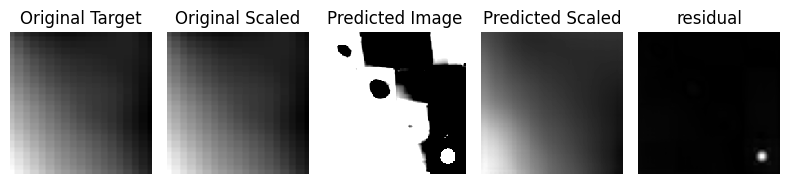

[VALID] epoch:  6 batch:  0 step:  20 loss:  0.44249770045280457 recon_detail loss:  (tensor(0.0044, device='mps:0'), tensor(0.2268, device='mps:0'), tensor(68.1155, device='mps:0'))


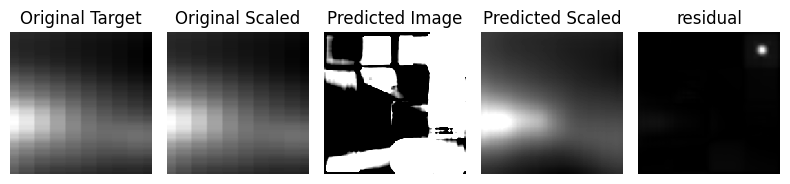

[VALID] epoch:  6 batch:  0 step:  40 loss:  0.42790350317955017 recon_detail loss:  (tensor(0.0043, device='mps:0'), tensor(0.2394, device='mps:0'), tensor(68.5864, device='mps:0'))


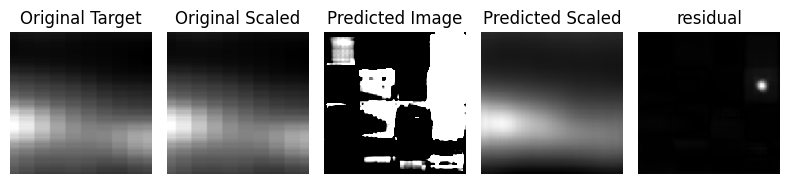

[VALID] epoch:  6 batch:  0 step:  60 loss:  0.4644884169101715 recon_detail loss:  (tensor(0.0046, device='mps:0'), tensor(0.2229, device='mps:0'), tensor(67.4371, device='mps:0'))


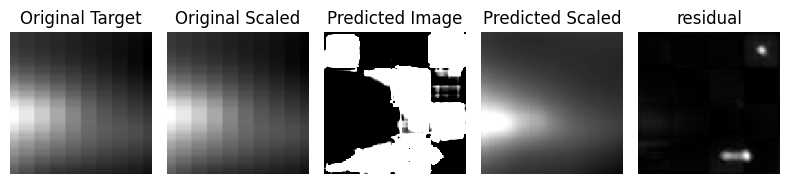

Epoch 7/1000, Train Loss: 5.608503e-01, Val Loss: 4.296459e-01
[TRAIN] epoch:  7 batch:  0 step:  50 loss:  0.6185809373855591 recon_detail loss:  (tensor(0.0062, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2805, device='mps:0'), tensor(64.5342, device='mps:0'))
BEFROE TRAIN


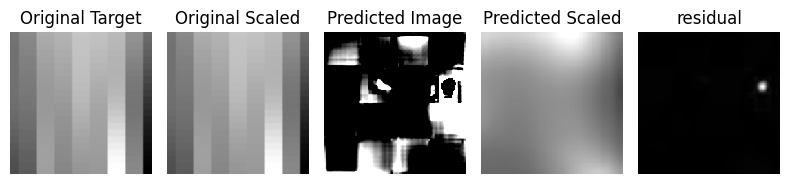

[TRAIN] epoch:  7 batch:  1 step:  100 loss:  0.4132045805454254 recon_detail loss:  (tensor(0.0041, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2122, device='mps:0'), tensor(69.0747, device='mps:0'))
BEFROE TRAIN


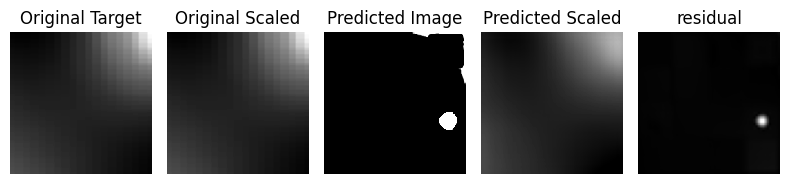

[TRAIN] epoch:  7 batch:  2 step:  150 loss:  0.35443586111068726 recon_detail loss:  (tensor(0.0035, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2369, device='mps:0'), tensor(59.1428, device='mps:0'))
BEFROE TRAIN


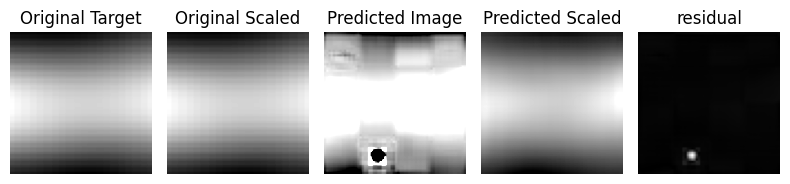

[TRAIN] epoch:  7 batch:  3 step:  200 loss:  0.42544692754745483 recon_detail loss:  (tensor(0.0043, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2336, device='mps:0'), tensor(67.9649, device='mps:0'))
BEFROE TRAIN


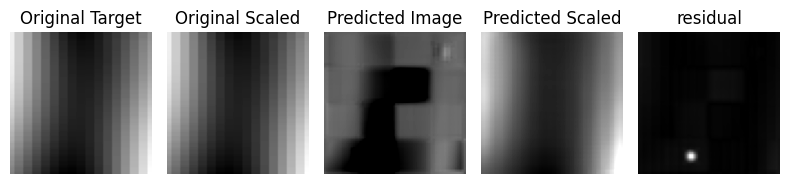

[TRAIN] epoch:  7 batch:  3 step:  250 loss:  0.43635275959968567 recon_detail loss:  (tensor(0.0044, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2389, device='mps:0'), tensor(66.9199, device='mps:0'))
BEFROE TRAIN


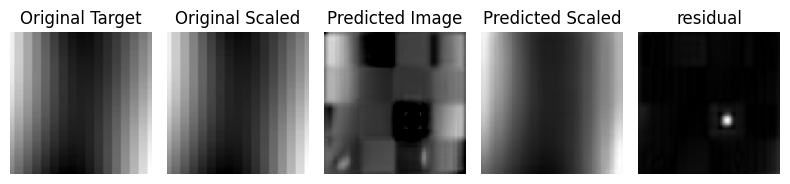

[TRAIN] epoch:  7 batch:  4 step:  300 loss:  0.4793355166912079 recon_detail loss:  (tensor(0.0048, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2306, device='mps:0'), tensor(66.6339, device='mps:0'))
BEFROE TRAIN


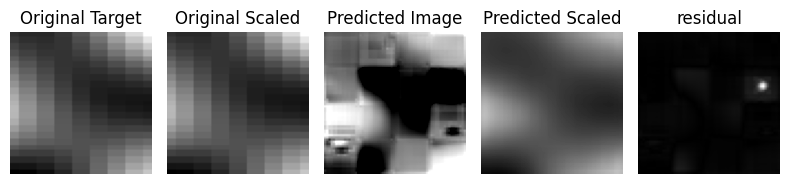

[TRAIN] epoch:  7 batch:  5 step:  350 loss:  0.3827652931213379 recon_detail loss:  (tensor(0.0038, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2523, device='mps:0'), tensor(65.4455, device='mps:0'))
BEFROE TRAIN


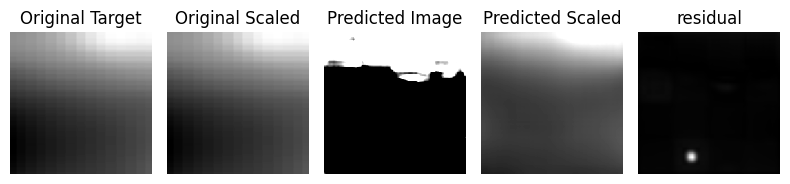

[VALID] epoch:  7 batch:  0 step:  20 loss:  0.392572820186615 recon_detail loss:  (tensor(0.0039, device='mps:0'), tensor(0.3080, device='mps:0'), tensor(462.7042, device='mps:0'))


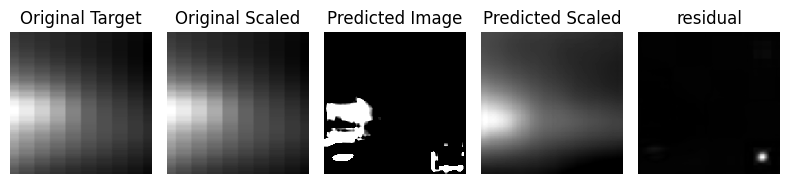

[VALID] epoch:  7 batch:  0 step:  40 loss:  0.3792130947113037 recon_detail loss:  (tensor(0.0038, device='mps:0'), tensor(0.3038, device='mps:0'), tensor(462.7872, device='mps:0'))


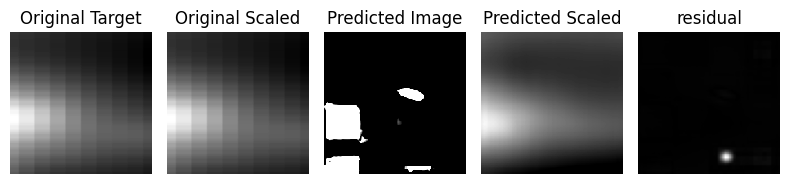

[VALID] epoch:  7 batch:  0 step:  60 loss:  0.3970984220504761 recon_detail loss:  (tensor(0.0040, device='mps:0'), tensor(0.3113, device='mps:0'), tensor(461.3977, device='mps:0'))


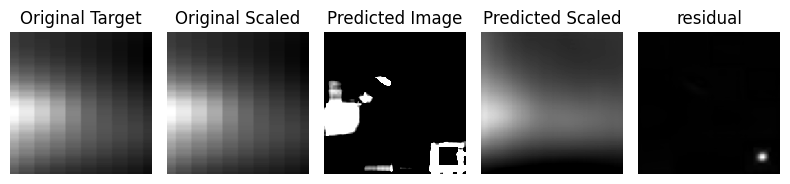

Epoch 8/1000, Train Loss: 4.396278e-01, Val Loss: 3.879627e-01
[TRAIN] epoch:  8 batch:  0 step:  50 loss:  0.31773239374160767 recon_detail loss:  (tensor(0.0032, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2297, device='mps:0'), tensor(62.5585, device='mps:0'))
BEFROE TRAIN


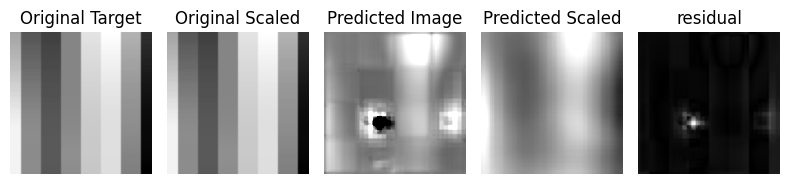

[TRAIN] epoch:  8 batch:  1 step:  100 loss:  0.4226206839084625 recon_detail loss:  (tensor(0.0042, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2427, device='mps:0'), tensor(62.1628, device='mps:0'))
BEFROE TRAIN


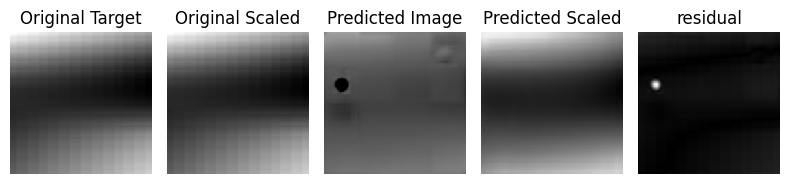

[TRAIN] epoch:  8 batch:  2 step:  150 loss:  0.36842289566993713 recon_detail loss:  (tensor(0.0037, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2414, device='mps:0'), tensor(66.2125, device='mps:0'))
BEFROE TRAIN


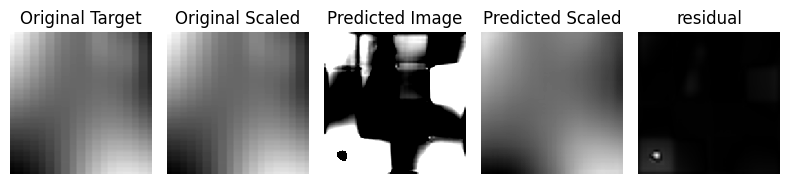

[TRAIN] epoch:  8 batch:  3 step:  200 loss:  0.5822775363922119 recon_detail loss:  (tensor(0.0058, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2383, device='mps:0'), tensor(63.9430, device='mps:0'))
BEFROE TRAIN


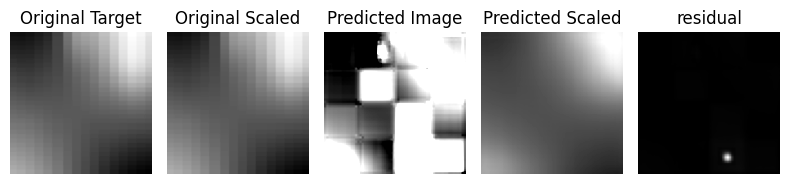

[TRAIN] epoch:  8 batch:  3 step:  250 loss:  0.5835436582565308 recon_detail loss:  (tensor(0.0058, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2484, device='mps:0'), tensor(63.6231, device='mps:0'))
BEFROE TRAIN


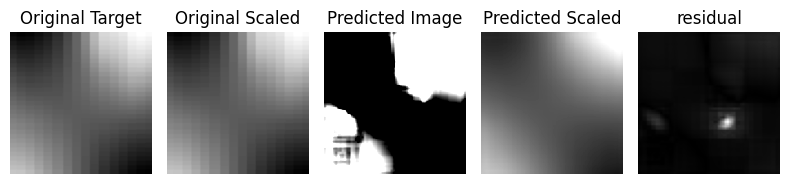

[TRAIN] epoch:  8 batch:  4 step:  300 loss:  0.3181443214416504 recon_detail loss:  (tensor(0.0032, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2597, device='mps:0'), tensor(62.8560, device='mps:0'))
BEFROE TRAIN


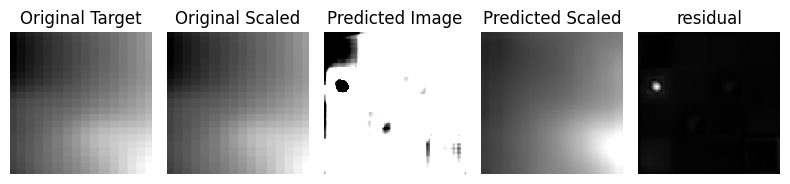

[TRAIN] epoch:  8 batch:  5 step:  350 loss:  0.33085212111473083 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2405, device='mps:0'), tensor(65.0707, device='mps:0'))
BEFROE TRAIN


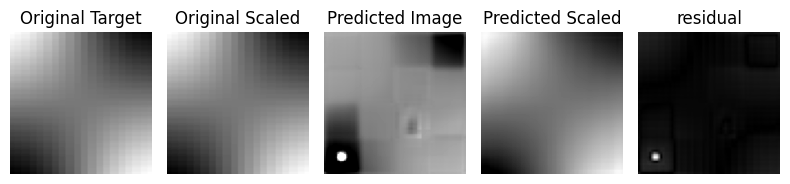

[VALID] epoch:  8 batch:  0 step:  20 loss:  0.3616757094860077 recon_detail loss:  (tensor(0.0036, device='mps:0'), tensor(0.2420, device='mps:0'), tensor(66.5790, device='mps:0'))


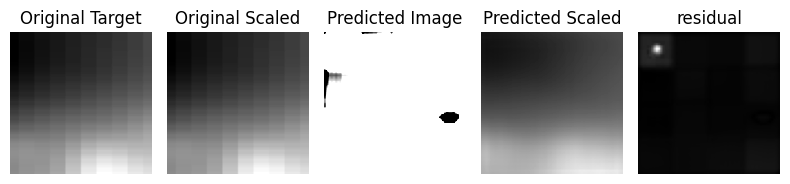

[VALID] epoch:  8 batch:  0 step:  40 loss:  0.3857397735118866 recon_detail loss:  (tensor(0.0039, device='mps:0'), tensor(0.2482, device='mps:0'), tensor(65.1839, device='mps:0'))


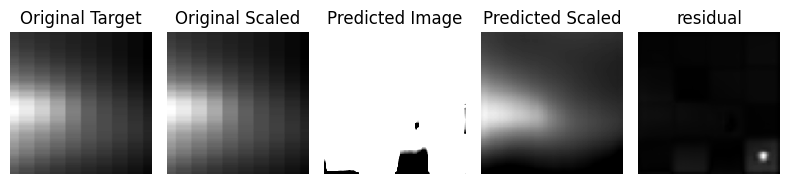

[VALID] epoch:  8 batch:  0 step:  60 loss:  0.37230241298675537 recon_detail loss:  (tensor(0.0037, device='mps:0'), tensor(0.2506, device='mps:0'), tensor(65.2093, device='mps:0'))


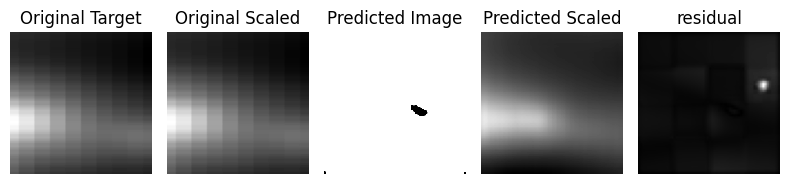

Epoch 9/1000, Train Loss: 3.976546e-01, Val Loss: 3.712688e-01
[TRAIN] epoch:  9 batch:  0 step:  50 loss:  0.3339708745479584 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2480, device='mps:0'), tensor(63.7246, device='mps:0'))
BEFROE TRAIN


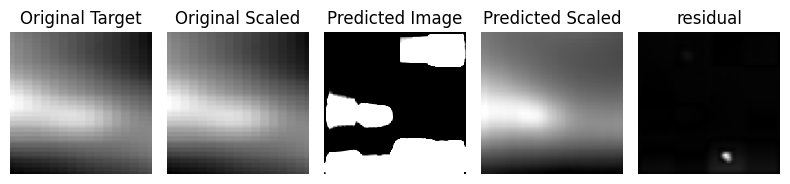

[TRAIN] epoch:  9 batch:  1 step:  100 loss:  0.40796881914138794 recon_detail loss:  (tensor(0.0041, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2168, device='mps:0'), tensor(68.0205, device='mps:0'))
BEFROE TRAIN


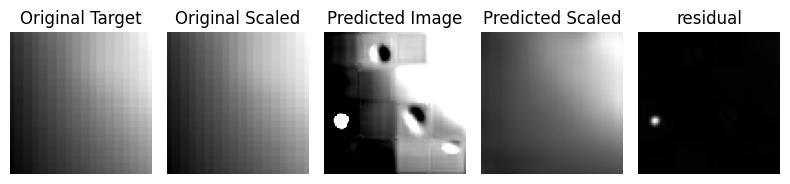

[TRAIN] epoch:  9 batch:  2 step:  150 loss:  0.2717663645744324 recon_detail loss:  (tensor(0.0027, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2242, device='mps:0'), tensor(59.3368, device='mps:0'))
BEFROE TRAIN


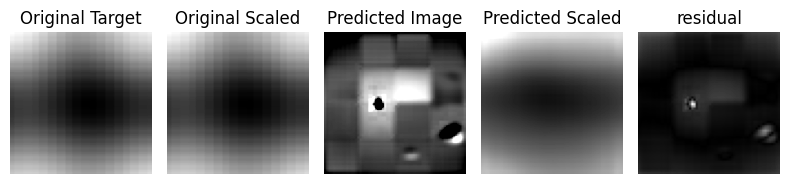

[TRAIN] epoch:  9 batch:  3 step:  200 loss:  0.42377394437789917 recon_detail loss:  (tensor(0.0042, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2487, device='mps:0'), tensor(62.5638, device='mps:0'))
BEFROE TRAIN


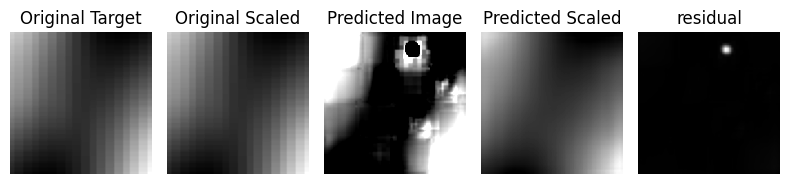

[TRAIN] epoch:  9 batch:  3 step:  250 loss:  0.4422750771045685 recon_detail loss:  (tensor(0.0044, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2605, device='mps:0'), tensor(61.6093, device='mps:0'))
BEFROE TRAIN


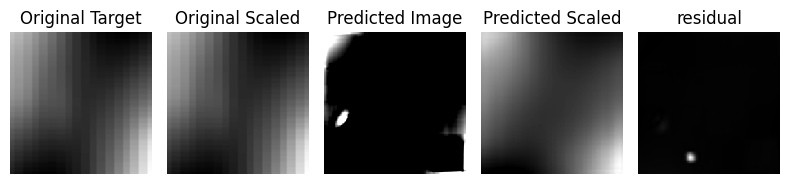

[TRAIN] epoch:  9 batch:  4 step:  300 loss:  0.3409242033958435 recon_detail loss:  (tensor(0.0034, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2204, device='mps:0'), tensor(62.4429, device='mps:0'))
BEFROE TRAIN


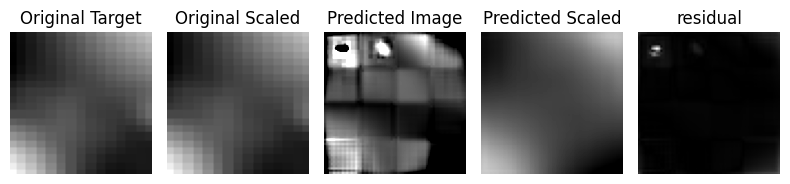

[TRAIN] epoch:  9 batch:  5 step:  350 loss:  0.25828561186790466 recon_detail loss:  (tensor(0.0026, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2525, device='mps:0'), tensor(63.5244, device='mps:0'))
BEFROE TRAIN


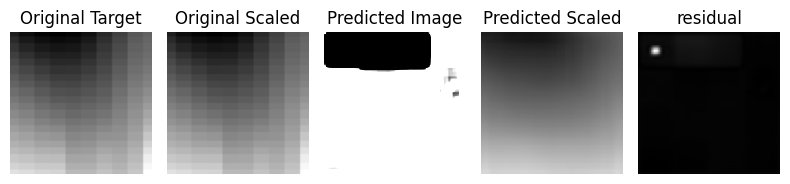

[VALID] epoch:  9 batch:  0 step:  20 loss:  0.33469322323799133 recon_detail loss:  (tensor(0.0033, device='mps:0'), tensor(0.2240, device='mps:0'), tensor(65.9039, device='mps:0'))


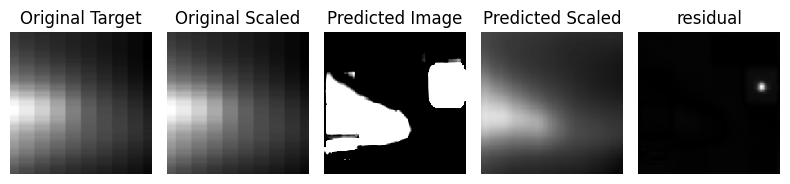

[VALID] epoch:  9 batch:  0 step:  40 loss:  0.30747517943382263 recon_detail loss:  (tensor(0.0031, device='mps:0'), tensor(0.2360, device='mps:0'), tensor(67.1695, device='mps:0'))


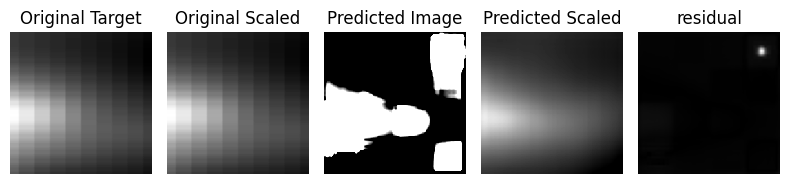

[VALID] epoch:  9 batch:  0 step:  60 loss:  0.33274298906326294 recon_detail loss:  (tensor(0.0033, device='mps:0'), tensor(0.2360, device='mps:0'), tensor(66.8358, device='mps:0'))


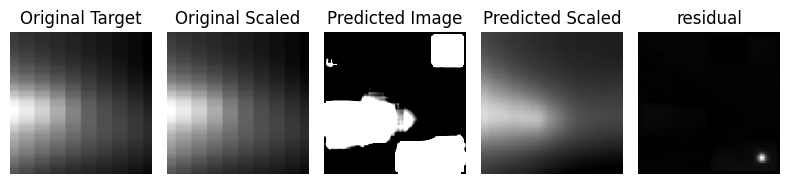

Epoch 10/1000, Train Loss: 3.659976e-01, Val Loss: 3.435164e-01
[TRAIN] epoch:  10 batch:  0 step:  50 loss:  0.5032191276550293 recon_detail loss:  (tensor(0.0050, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2435, device='mps:0'), tensor(65.8919, device='mps:0'))
BEFROE TRAIN


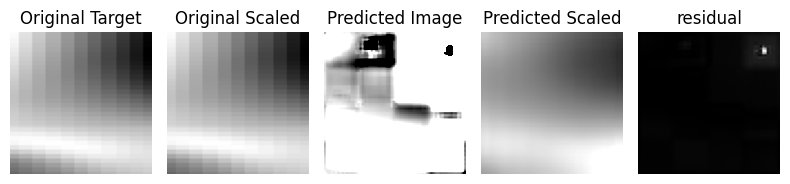

[TRAIN] epoch:  10 batch:  1 step:  100 loss:  0.2762333154678345 recon_detail loss:  (tensor(0.0028, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2164, device='mps:0'), tensor(66.6852, device='mps:0'))
BEFROE TRAIN


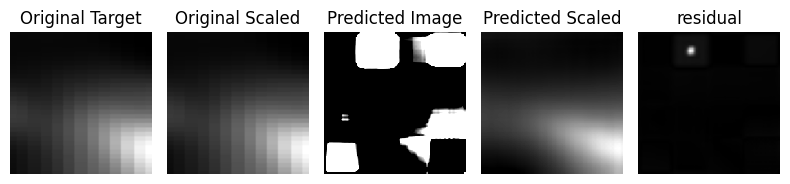

[TRAIN] epoch:  10 batch:  2 step:  150 loss:  0.36196956038475037 recon_detail loss:  (tensor(0.0036, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2355, device='mps:0'), tensor(60.8905, device='mps:0'))
BEFROE TRAIN


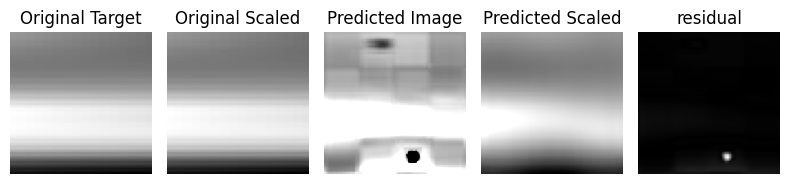

[TRAIN] epoch:  10 batch:  3 step:  200 loss:  0.3753794729709625 recon_detail loss:  (tensor(0.0038, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2359, device='mps:0'), tensor(67.3348, device='mps:0'))
BEFROE TRAIN


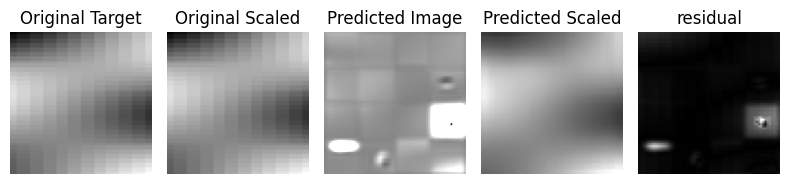

[TRAIN] epoch:  10 batch:  3 step:  250 loss:  0.32082289457321167 recon_detail loss:  (tensor(0.0032, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2439, device='mps:0'), tensor(66.5195, device='mps:0'))
BEFROE TRAIN


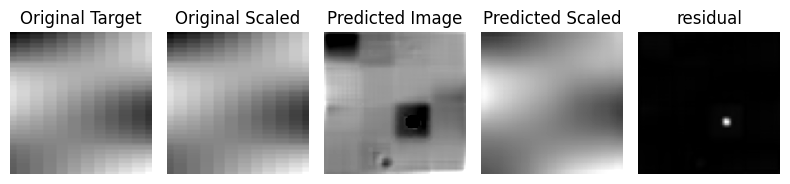

[TRAIN] epoch:  10 batch:  4 step:  300 loss:  0.2017146497964859 recon_detail loss:  (tensor(0.0020, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2391, device='mps:0'), tensor(65.1629, device='mps:0'))
BEFROE TRAIN


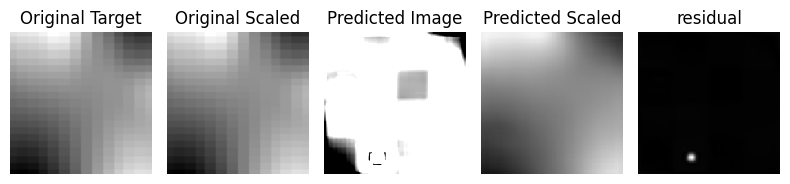

[TRAIN] epoch:  10 batch:  5 step:  350 loss:  0.26762130856513977 recon_detail loss:  (tensor(0.0027, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2289, device='mps:0'), tensor(65.2559, device='mps:0'))
BEFROE TRAIN


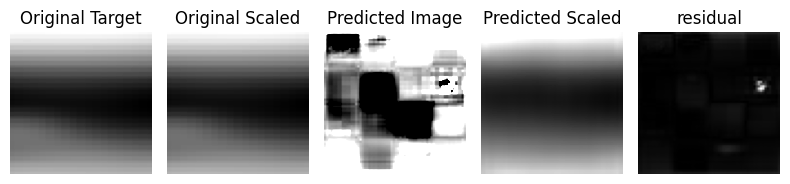

[VALID] epoch:  10 batch:  0 step:  20 loss:  0.3405182361602783 recon_detail loss:  (tensor(0.0034, device='mps:0'), tensor(0.2361, device='mps:0'), tensor(63.8615, device='mps:0'))


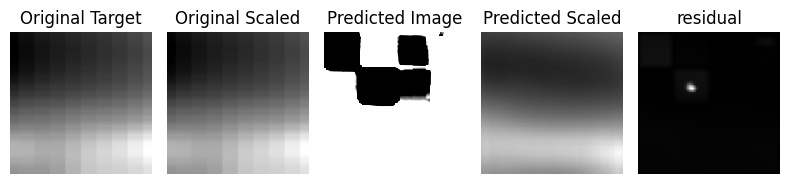

[VALID] epoch:  10 batch:  0 step:  40 loss:  0.33955439925193787 recon_detail loss:  (tensor(0.0034, device='mps:0'), tensor(0.2342, device='mps:0'), tensor(64.2657, device='mps:0'))


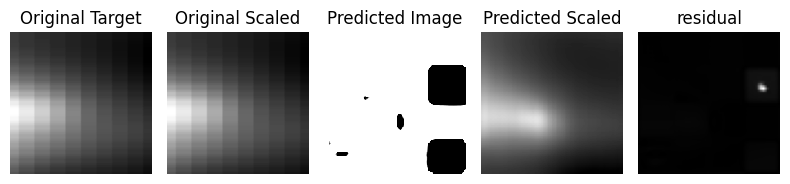

[VALID] epoch:  10 batch:  0 step:  60 loss:  0.33568915724754333 recon_detail loss:  (tensor(0.0034, device='mps:0'), tensor(0.2297, device='mps:0'), tensor(63.1448, device='mps:0'))


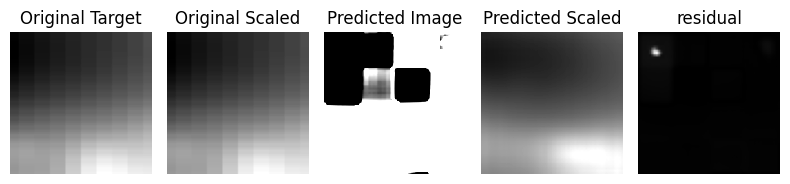

Epoch 11/1000, Train Loss: 3.511965e-01, Val Loss: 3.371783e-01
[TRAIN] epoch:  11 batch:  0 step:  50 loss:  0.32584381103515625 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2352, device='mps:0'), tensor(61.3230, device='mps:0'))
BEFROE TRAIN


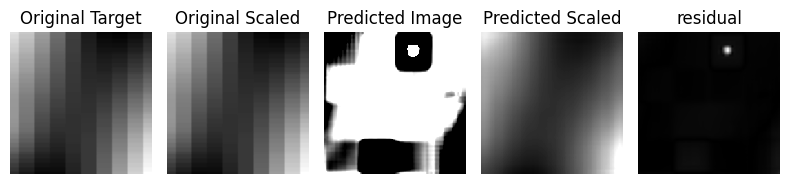

[TRAIN] epoch:  11 batch:  1 step:  100 loss:  0.5062429904937744 recon_detail loss:  (tensor(0.0051, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2346, device='mps:0'), tensor(61.9624, device='mps:0'))
BEFROE TRAIN


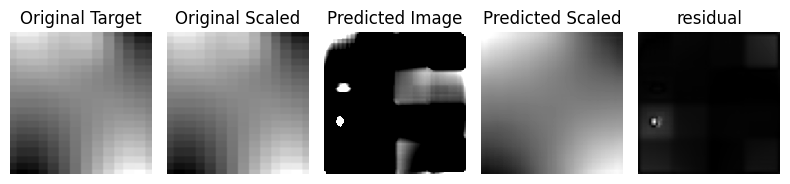

[TRAIN] epoch:  11 batch:  2 step:  150 loss:  0.30717507004737854 recon_detail loss:  (tensor(0.0031, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2522, device='mps:0'), tensor(66.8799, device='mps:0'))
BEFROE TRAIN


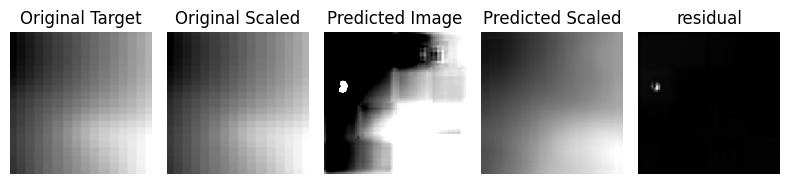

[TRAIN] epoch:  11 batch:  3 step:  200 loss:  0.3327149748802185 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2194, device='mps:0'), tensor(73.7527, device='mps:0'))
BEFROE TRAIN


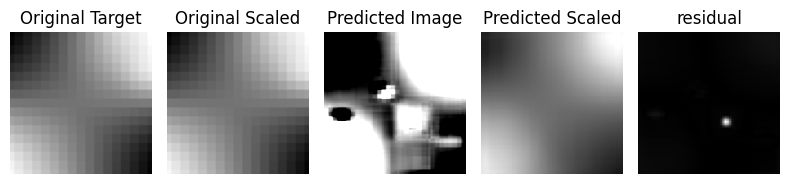

[TRAIN] epoch:  11 batch:  3 step:  250 loss:  0.2730380892753601 recon_detail loss:  (tensor(0.0027, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2156, device='mps:0'), tensor(71.9257, device='mps:0'))
BEFROE TRAIN


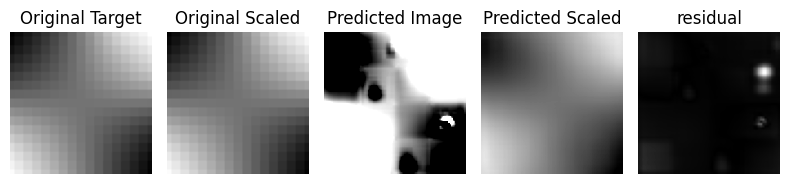

[TRAIN] epoch:  11 batch:  4 step:  300 loss:  0.2957473397254944 recon_detail loss:  (tensor(0.0030, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2606, device='mps:0'), tensor(66.7119, device='mps:0'))
BEFROE TRAIN


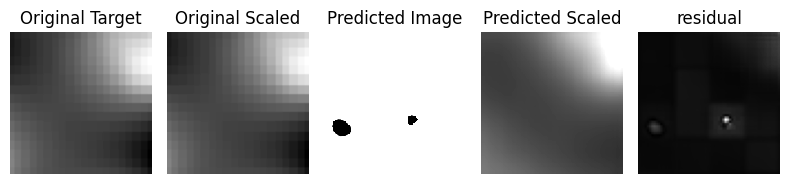

[TRAIN] epoch:  11 batch:  5 step:  350 loss:  0.710571825504303 recon_detail loss:  (tensor(0.0071, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2709, device='mps:0'), tensor(67.3922, device='mps:0'))
BEFROE TRAIN


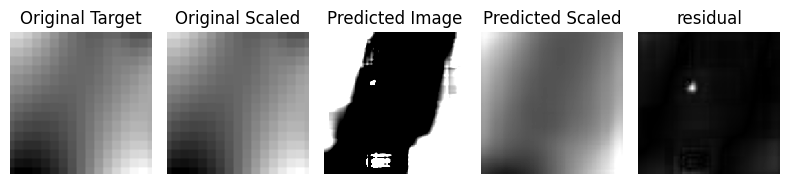

[VALID] epoch:  11 batch:  0 step:  20 loss:  0.4583389163017273 recon_detail loss:  (tensor(0.0046, device='mps:0'), tensor(0.2764, device='mps:0'), tensor(67.0446, device='mps:0'))


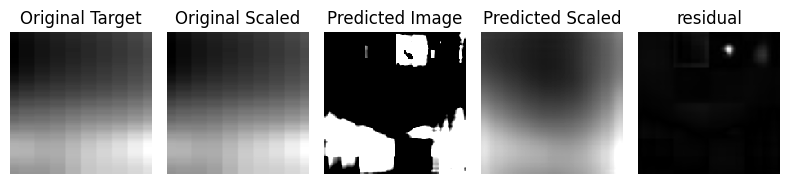

[VALID] epoch:  11 batch:  0 step:  40 loss:  0.5400573015213013 recon_detail loss:  (tensor(0.0054, device='mps:0'), tensor(0.2779, device='mps:0'), tensor(66.1888, device='mps:0'))


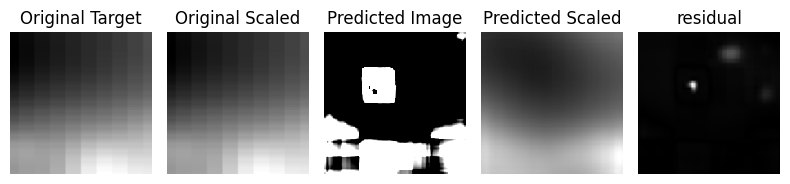

[VALID] epoch:  11 batch:  0 step:  60 loss:  0.3463931083679199 recon_detail loss:  (tensor(0.0035, device='mps:0'), tensor(0.2656, device='mps:0'), tensor(67.0494, device='mps:0'))


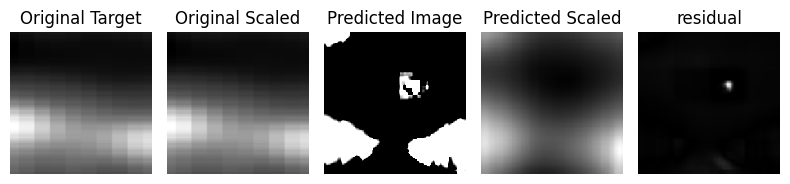

Epoch 12/1000, Train Loss: 3.815500e-01, Val Loss: 3.905684e-01
[TRAIN] epoch:  12 batch:  0 step:  50 loss:  0.2226584106683731 recon_detail loss:  (tensor(0.0022, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2391, device='mps:0'), tensor(65.5861, device='mps:0'))
BEFROE TRAIN


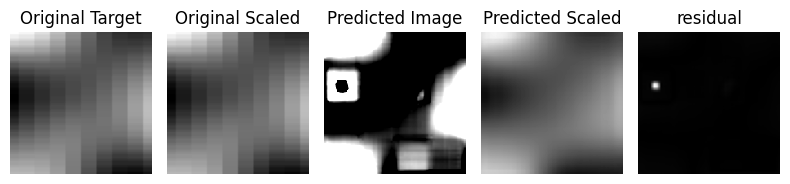

[TRAIN] epoch:  12 batch:  1 step:  100 loss:  0.4808564782142639 recon_detail loss:  (tensor(0.0048, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2295, device='mps:0'), tensor(66.3259, device='mps:0'))
BEFROE TRAIN


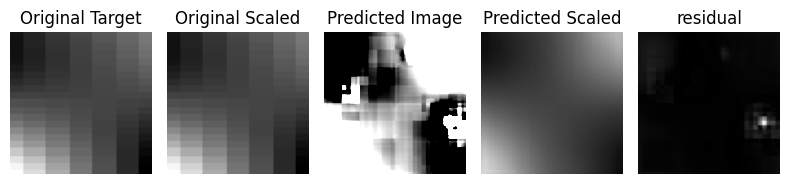

[TRAIN] epoch:  12 batch:  2 step:  150 loss:  0.27666088938713074 recon_detail loss:  (tensor(0.0028, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2503, device='mps:0'), tensor(58.3729, device='mps:0'))
BEFROE TRAIN


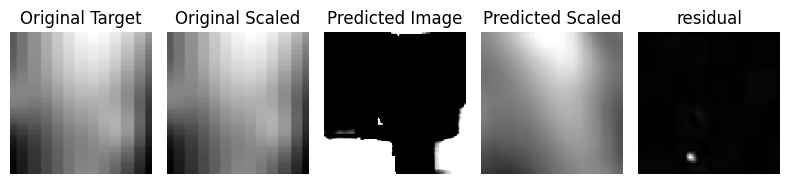

[TRAIN] epoch:  12 batch:  3 step:  200 loss:  0.37738844752311707 recon_detail loss:  (tensor(0.0038, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2451, device='mps:0'), tensor(59.6217, device='mps:0'))
BEFROE TRAIN


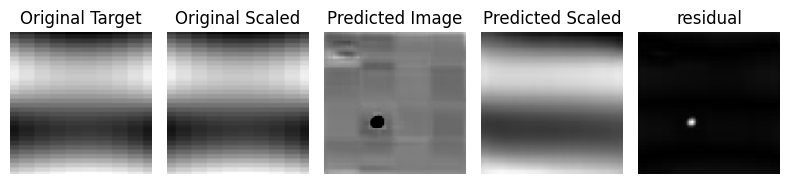

[TRAIN] epoch:  12 batch:  3 step:  250 loss:  0.3018205165863037 recon_detail loss:  (tensor(0.0030, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2420, device='mps:0'), tensor(59.5253, device='mps:0'))
BEFROE TRAIN


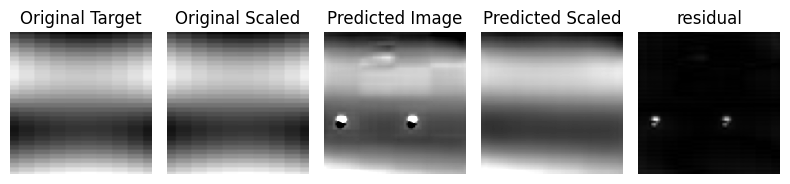

[TRAIN] epoch:  12 batch:  4 step:  300 loss:  0.3843933343887329 recon_detail loss:  (tensor(0.0038, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2607, device='mps:0'), tensor(64.3755, device='mps:0'))
BEFROE TRAIN


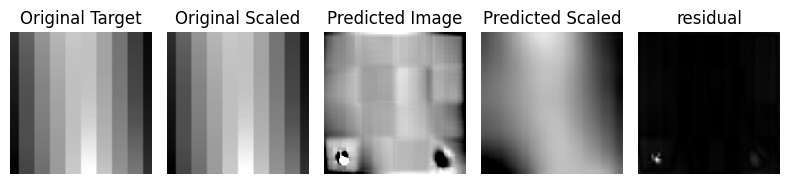

[TRAIN] epoch:  12 batch:  5 step:  350 loss:  0.457406610250473 recon_detail loss:  (tensor(0.0046, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2145, device='mps:0'), tensor(70.3594, device='mps:0'))
BEFROE TRAIN


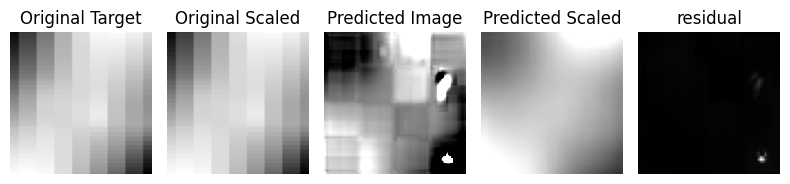

[VALID] epoch:  12 batch:  0 step:  20 loss:  0.31963613629341125 recon_detail loss:  (tensor(0.0032, device='mps:0'), tensor(0.2183, device='mps:0'), tensor(70.4343, device='mps:0'))


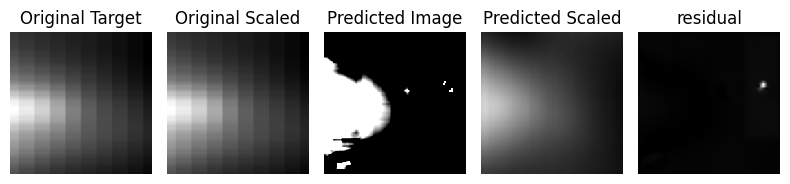

[VALID] epoch:  12 batch:  0 step:  40 loss:  0.33400973677635193 recon_detail loss:  (tensor(0.0033, device='mps:0'), tensor(0.2160, device='mps:0'), tensor(68.2933, device='mps:0'))


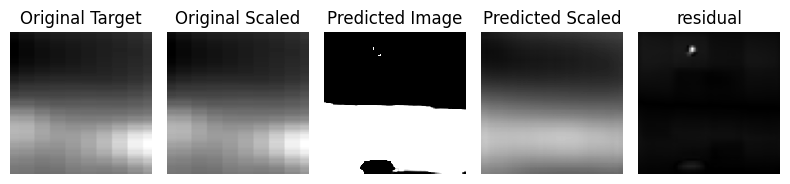

[VALID] epoch:  12 batch:  0 step:  60 loss:  0.3117470145225525 recon_detail loss:  (tensor(0.0031, device='mps:0'), tensor(0.2281, device='mps:0'), tensor(68.7576, device='mps:0'))


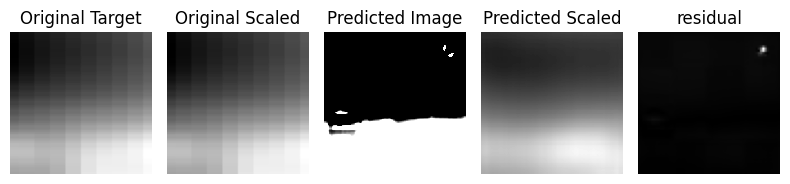

Epoch 13/1000, Train Loss: 3.584801e-01, Val Loss: 3.443295e-01


KeyboardInterrupt: 

In [1]:
import torch
import torch.nn.functional as F
from fem_dataset_to_image_full_mesh_diffusion import FemImageDataset as MeshDataset
from fem_model import ScalingVAE5
import json
from torch.utils.data import DataLoader
from utils import EarlyStopping
import gc
import numpy as np
import matplotlib.pyplot as plt


early_stopping = EarlyStopping(
    patience=5,     # FEM/GNN은 15~30 권장
    min_delta=1e-5,  # loss 스케일에 맞게
    mode="min"
)
def collate_flatten(batch): 
    images, conds = [], [] 
    batch_size=len(batch) 
    step_num_in_batch=len(batch[0]["image"]) 
    idxs=[] 
    for i in range(batch_size): 
        idx = torch.randperm(len(batch[0]["image"])) 
        idxs.append(idx) 
        # print(batch[i]['min_max'])
    idxs=np.array(idxs).T 

    for i in range(step_num_in_batch): 
        batch_images=[] 
        batch_conds=[] 
        for b_i,b in enumerate(batch): 
            id=idxs[i][b_i] 
            batch_images.append(b['image'][id]) 
            batch_conds.append(b['cond'][id]) 
        images.append(batch_images) 
        conds.append(batch_conds) 
    return { "image": images, "cond": conds, }

def draw(data1,data1_1,data2,data3,model_param): 
    
    plt.figure(figsize=(8, 4)) 
    plt.subplot(1, 5, 1) 
    plt.imshow(data1.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max()) 
    plt.title("Original Target") 
    plt.axis("off")
    plt.subplot(1, 5, 2) 
    plt.imshow(data1_1.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max()) 
    plt.title("Original Scaled") 
    plt.axis("off") 
    plt.subplot(1, 5, 3) 
    plt.imshow(data2.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max())
    plt.title("Predicted Image") 
    plt.axis("off") 
    plt.subplot(1, 5, 4) 
    plt.imshow(data3.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max())
    plt.title("Predicted Scaled") 
    plt.axis("off")
    plt.subplot(1, 5, 5) 
    plt.imshow(np.abs(data1.cpu().detach().numpy()-data2.cpu().detach().numpy()), cmap="gray")
    plt.title("residual") 
    plt.axis("off")
    plt.tight_layout() 
    plt.show()

def kl_divergence_gaussian(mu, logvar, clamp=(-0.3, 0.3)):
    """
    KL( N(mu, var) || N(0, I) )
    Supports mu/logvar with shape:
      [B, Z] or [B, C, H, W] or [B, ...]
    """
    if clamp is not None:
        logvar = torch.clamp(logvar, min=clamp[0], max=clamp[1])

    # flatten all non-batch dimensions
    mu = mu.view(mu.size(0), -1)
    logvar = logvar.view(logvar.size(0), -1)

    kl = 0.5 * torch.sum(
        torch.exp(logvar) + mu**2 - 1.0 - logvar,
        dim=1
    )

    return kl.mean()

def charbonnier_loss(pred: torch.Tensor,
                     target: torch.Tensor,
                     eps: float = 1e-8,
                     reduction: str = "mean") -> torch.Tensor:
    """
    Charbonnier loss (a smooth L1 / pseudo-Huber variant):
        L = sqrt((pred - target)^2 + eps^2)

    Args:
        pred, target: same shape tensors
        eps: smoothing term (bigger -> more L1-like near 0)
        reduction: "mean" | "sum" | "none"

    Returns:
        loss tensor (scalar if reduced)
    """
    if pred.shape != target.shape:
        raise ValueError(f"Shape mismatch: pred{pred.shape} vs target{target.shape}")

    diff = pred - target
    loss = torch.sqrt(diff * diff + eps * eps)

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    if reduction == "none":
        return loss
    raise ValueError("reduction must be one of {'mean','sum','none'}")




def GradientDifferenceLossCharbonnier( pred, target):
    grad_pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    grad_target_x = target[:, :, :, 1:] - target[:, :, :, :-1]

    grad_pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    grad_target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    return (
        charbonnier_loss(grad_pred_x, grad_target_x) +
        charbonnier_loss(grad_pred_y, grad_target_y)
    )

def cvae_loss(target_x_norm,target,scaled_x_hat, x_hat,mean,std, mu, logvar,epoch, beta=1e-3): 
    recon= charbonnier_loss(target, x_hat)
    recon_2 = GradientDifferenceLossCharbonnier(target,x_hat)
    recon_detail = charbonnier_loss(target_x_norm, scaled_x_hat)
    recon_detail_2 = GradientDifferenceLossCharbonnier(target_x_norm,scaled_x_hat)
    recon_sum=0.8*recon +0.2*recon_2
    recon_detail_sum=0.8*recon_detail +0.2*recon_detail_2
    
    kl = kl_divergence_gaussian(mu, logvar)
    #return (0.8-0.4*epoch/100)*recon_detail +0.05*recon_detail_2+0.1*latent_mean+(0.1+0.4*epoch/100)*latent_logvar+ beta * kl, (recon_detail ,latent_mean,latent_logvar, kl)
    scale=100
    # if epoch<=3:
    #     scale=1
    # elif epoch >3 and epoch<=6:
    #     scale=100
    # elif epoch >6 and epoch<=9:
    #     scale=1000
    # elif epoch >9 and epoch<=15:
    #     scale=2000
    # else:
    #     scale=5000
    return scale*recon_sum  , (recon_sum,recon_detail_sum, kl)

def draw_latent(z): 

    z = z.view(z.size(0), -1) 
    plt.figure(figsize=(8, 4)) 
    plt.hist(z.flatten().detach().cpu(), bins=100) 
    plt.title("Image 1") 
    plt.show()

def train_one_epoch(model, loader, device, opt, model_param,epoch): 
    model.train() 
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            opt.zero_grad() 
            loss.backward() 
            opt.step() 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[TRAIN] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                print('BEFROE TRAIN')
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)
@torch.no_grad()
def eval_one_epoch(model, loader, device,  model_param,epoch):
    model.eval()
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            total += float(loss.item())
            count+=1 
            if count % 20 == 0: 
                print('[VALID] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)

def main():
    root = "./data"
    if torch.cuda.is_available() :
        device='cuda'
    elif torch.backends.mps.is_available() :
        device='mps'
    else :
        device='cpu'

    model_param={ 'in_channels':3, 
                'out_channels':3,
                'GRID':64,
                'loss_scale':1.0,
                'learning_rate':1e-3,
                'num_epochs':1000,
                'base':128,
                'latent_dim':64,
                'batch_size':128,
                'depth':4 } 
    
    train_ds = MeshDataset(root_dir=root,type='train',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 
    val_ds= MeshDataset(root_dir=root,type='valid',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 

    train_loader = DataLoader(train_ds, batch_size=model_param['batch_size'], shuffle=True, collate_fn=collate_flatten) 
    val_loader = DataLoader(val_ds, batch_size=model_param['batch_size'], shuffle=False, collate_fn=collate_flatten) 
    example = train_ds[0] 
    model_param['cond_dim']=len(example['cond'][0]) 
    model_param['dataset_scale_info']=train_ds.scale_info 

    model = ScalingVAE5( in_channels=model_param['in_channels'], 
                latent_dim=model_param['latent_dim'], 
                base=model_param['base'],
                depth=model_param['depth'] ).to(device)
    ckpt = torch.load("mesh_invariant_diffustion_vae4_3_epoch005.pt", map_location=device)
    model.load_state_dict(ckpt)
    model.to(device)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.decoder.avg_layers.parameters():
        p.requires_grad = True
    for p in model.decoder.std_layers.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=model_param['learning_rate'], weight_decay=1e-6)
    loss_dict={}
    for epoch in range(model_param['num_epochs']):        
        epoch=epoch+6
        train_loss = train_one_epoch(model, train_loader, device, optimizer,model_param,epoch)
        val_loss = eval_one_epoch(model, val_loader, device,model_param,epoch)
        loss_dict[epoch] = {'train_loss':train_loss, 'val_loss':val_loss}   
        print(f"Epoch {epoch+1}/{model_param['num_epochs']}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}")  
        improved = early_stopping.step(val_loss)
        with open(f"loss_history_diffustion_vae4_3.json", "w", encoding="utf-8") as f:
            json.dump(loss_dict, f, indent=2)
        if improved:
            best_val = val_loss
            # print(eval_one_epoch_sample_mse(model, val_loader, device, sched))
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_early_epoch{str(epoch).zfill(3)}.pt")  # best만 저장

            with open(f"model_param_diffustion_vae4_3_early.json", "w", encoding="utf-8") as f:
                json.dump(model_param, f, indent=2)
        if early_stopping.should_stop:
            print(
                f"\n Early stopping at epoch {epoch} "
                f"(best val = {best_val:.6e})"
            )
            break
        if epoch%5==0:
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_epoch{str(epoch).zfill(3)}.pt")
    torch.save(model.state_dict(), "mesh_invariant_diffustion_vae4_3.pt")
    with open(f"model_param_diffusion_vae4_3.json", "w", encoding="utf-8") as f:
        json.dump(model_param, f, indent=2) 

if __name__ == "__main__":
    main()

100%|██████████| 805/805 [00:05<00:00, 154.17it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...


100%|██████████| 805/805 [00:05<00:00, 152.53it/s]


Loading FEM graph dataset...
Build Complete FEM graph dataset...
[TRAIN] epoch:  11 batch:  0 step:  50 loss:  0.04040636867284775 recon_detail loss:  (tensor(0.0040, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2277, device='mps:0'), tensor(71.0752, device='mps:0'))
BEFROE TRAIN


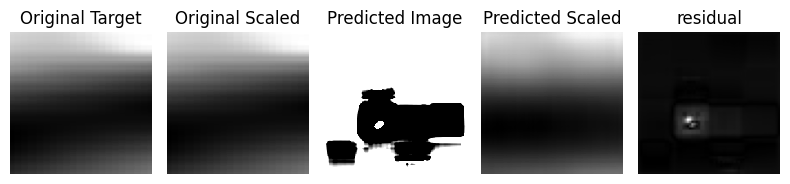

[TRAIN] epoch:  11 batch:  1 step:  100 loss:  0.04974859952926636 recon_detail loss:  (tensor(0.0050, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2401, device='mps:0'), tensor(65.9619, device='mps:0'))
BEFROE TRAIN


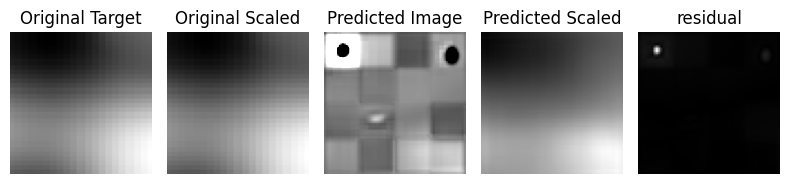

[TRAIN] epoch:  11 batch:  2 step:  150 loss:  0.03737024590373039 recon_detail loss:  (tensor(0.0037, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2431, device='mps:0'), tensor(60.8739, device='mps:0'))
BEFROE TRAIN


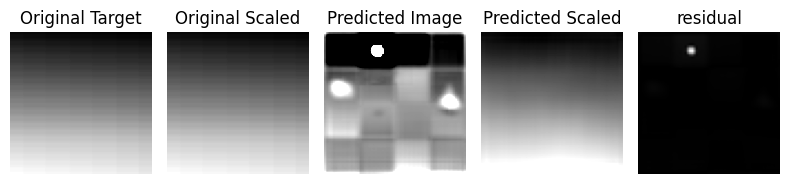

[TRAIN] epoch:  11 batch:  3 step:  200 loss:  0.03923056647181511 recon_detail loss:  (tensor(0.0039, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2480, device='mps:0'), tensor(69.2558, device='mps:0'))
BEFROE TRAIN


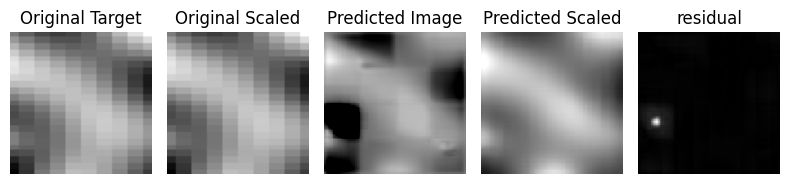

[TRAIN] epoch:  11 batch:  3 step:  250 loss:  0.02530297078192234 recon_detail loss:  (tensor(0.0025, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2428, device='mps:0'), tensor(68.6585, device='mps:0'))
BEFROE TRAIN


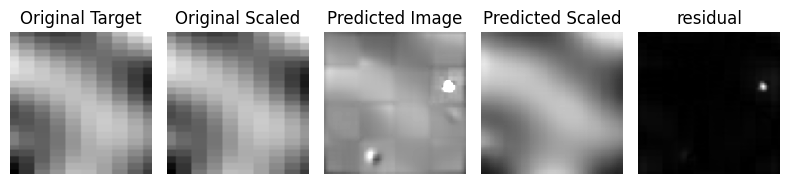

[TRAIN] epoch:  11 batch:  4 step:  300 loss:  0.03258519619703293 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2151, device='mps:0'), tensor(63.4804, device='mps:0'))
BEFROE TRAIN


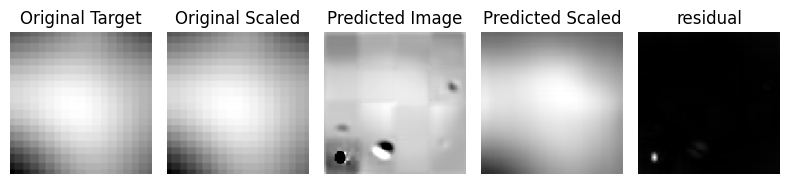

[TRAIN] epoch:  11 batch:  5 step:  350 loss:  0.029634539037942886 recon_detail loss:  (tensor(0.0030, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2227, device='mps:0'), tensor(66.0517, device='mps:0'))
BEFROE TRAIN


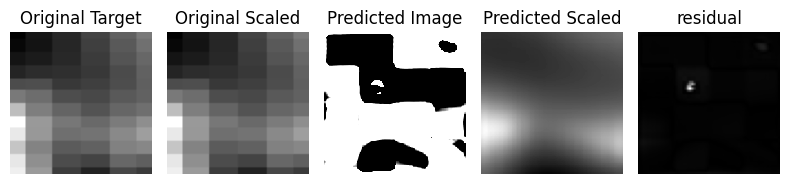

[VALID] epoch:  11 batch:  0 step:  20 loss:  0.02624010294675827 recon_detail loss:  (tensor(0.0026, device='mps:0'), tensor(0.2390, device='mps:0'), tensor(64.4442, device='mps:0'))


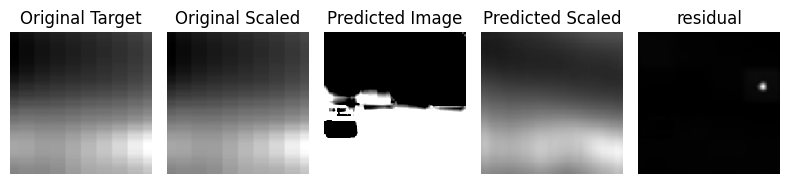

[VALID] epoch:  11 batch:  0 step:  40 loss:  0.026355519890785217 recon_detail loss:  (tensor(0.0026, device='mps:0'), tensor(0.2352, device='mps:0'), tensor(65.2901, device='mps:0'))


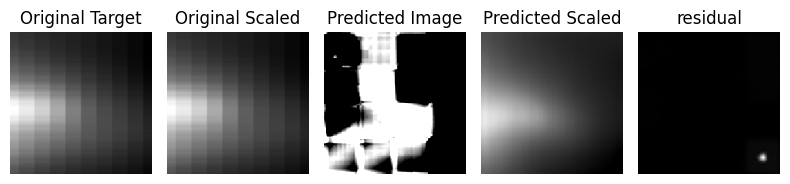

[VALID] epoch:  11 batch:  0 step:  60 loss:  0.028912853449583054 recon_detail loss:  (tensor(0.0029, device='mps:0'), tensor(0.2281, device='mps:0'), tensor(64.6421, device='mps:0'))


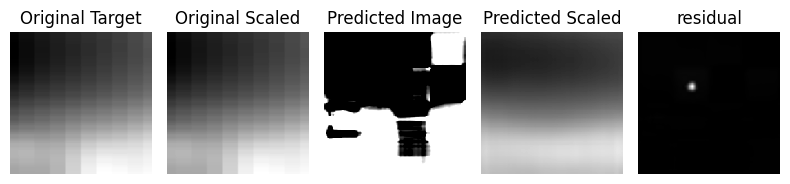

Epoch 12/1000, Train Loss: 4.009522e-02, Val Loss: 2.805761e-02
[TRAIN] epoch:  12 batch:  0 step:  50 loss:  0.03457677364349365 recon_detail loss:  (tensor(0.0035, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2254, device='mps:0'), tensor(60.8942, device='mps:0'))
BEFROE TRAIN


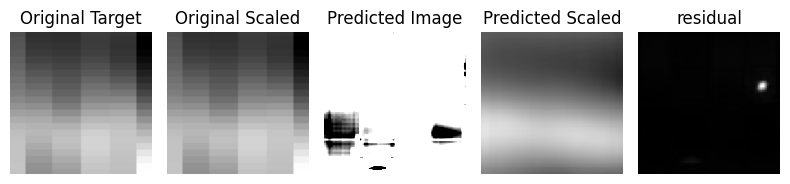

[TRAIN] epoch:  12 batch:  1 step:  100 loss:  0.02455975115299225 recon_detail loss:  (tensor(0.0025, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2403, device='mps:0'), tensor(64.7737, device='mps:0'))
BEFROE TRAIN


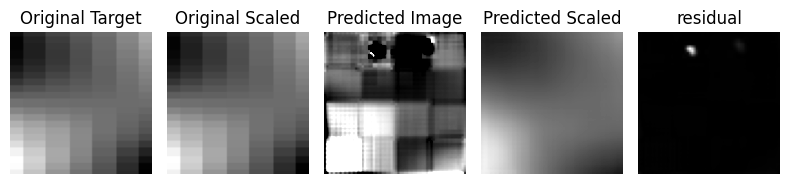

[TRAIN] epoch:  12 batch:  2 step:  150 loss:  0.03377141058444977 recon_detail loss:  (tensor(0.0034, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2239, device='mps:0'), tensor(64.1521, device='mps:0'))
BEFROE TRAIN


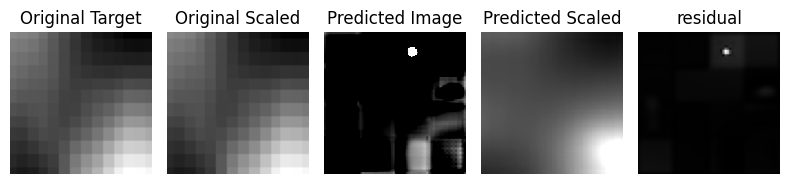

[TRAIN] epoch:  12 batch:  3 step:  200 loss:  0.02782011777162552 recon_detail loss:  (tensor(0.0028, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2233, device='mps:0'), tensor(64.6750, device='mps:0'))
BEFROE TRAIN


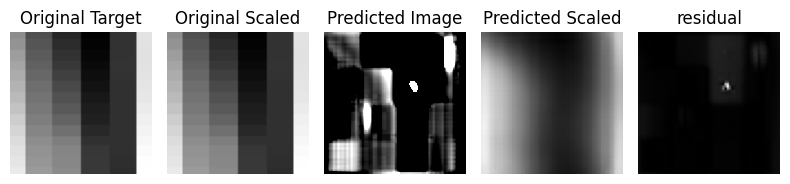

[TRAIN] epoch:  12 batch:  3 step:  250 loss:  0.03398074954748154 recon_detail loss:  (tensor(0.0034, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2179, device='mps:0'), tensor(65.3649, device='mps:0'))
BEFROE TRAIN


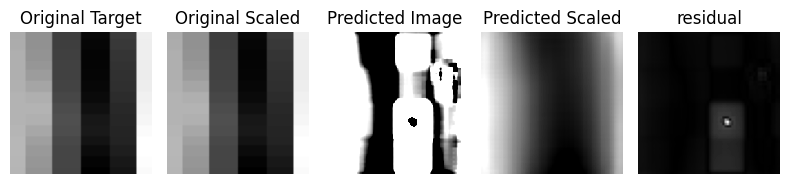

[TRAIN] epoch:  12 batch:  4 step:  300 loss:  0.04799198731780052 recon_detail loss:  (tensor(0.0048, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2577, device='mps:0'), tensor(65.2429, device='mps:0'))
BEFROE TRAIN


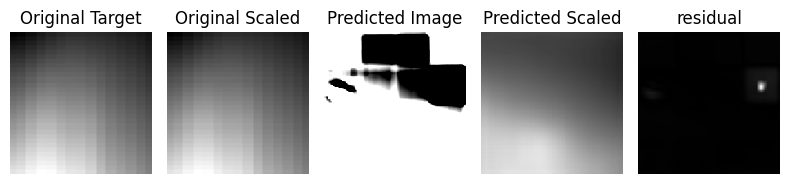

[TRAIN] epoch:  12 batch:  5 step:  350 loss:  0.041404567658901215 recon_detail loss:  (tensor(0.0041, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2482, device='mps:0'), tensor(61.1093, device='mps:0'))
BEFROE TRAIN


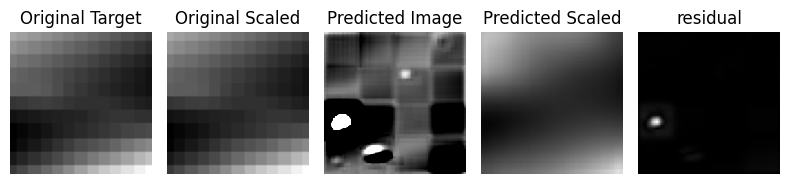

[VALID] epoch:  12 batch:  0 step:  20 loss:  0.03483790159225464 recon_detail loss:  (tensor(0.0035, device='mps:0'), tensor(0.2372, device='mps:0'), tensor(60.2728, device='mps:0'))


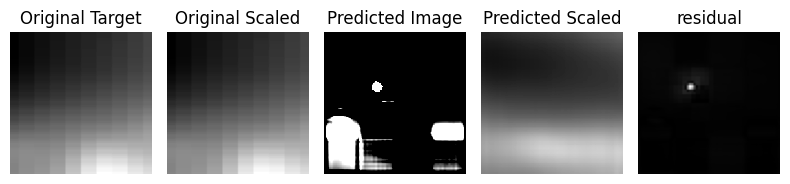

[VALID] epoch:  12 batch:  0 step:  40 loss:  0.03315582871437073 recon_detail loss:  (tensor(0.0033, device='mps:0'), tensor(0.2434, device='mps:0'), tensor(62.1152, device='mps:0'))


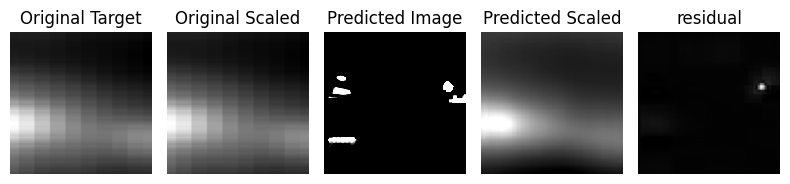

[VALID] epoch:  12 batch:  0 step:  60 loss:  0.03512779623270035 recon_detail loss:  (tensor(0.0035, device='mps:0'), tensor(0.2309, device='mps:0'), tensor(60.3488, device='mps:0'))


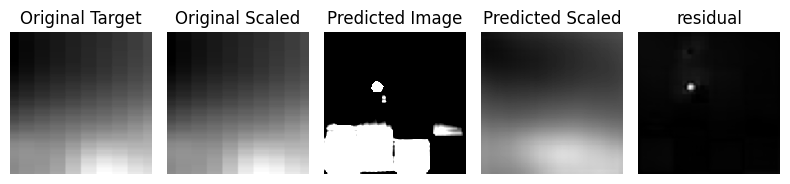

Epoch 13/1000, Train Loss: 3.555274e-02, Val Loss: 3.374608e-02
[TRAIN] epoch:  13 batch:  0 step:  50 loss:  0.03770631179213524 recon_detail loss:  (tensor(0.0038, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2191, device='mps:0'), tensor(60.9432, device='mps:0'))
BEFROE TRAIN


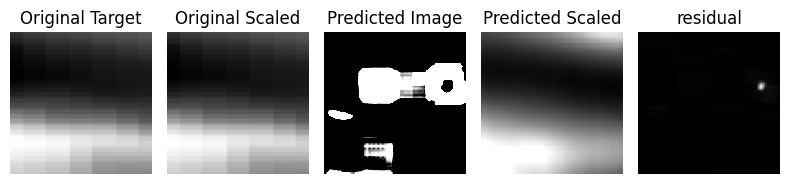

[TRAIN] epoch:  13 batch:  1 step:  100 loss:  0.022591985762119293 recon_detail loss:  (tensor(0.0023, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2247, device='mps:0'), tensor(63.9170, device='mps:0'))
BEFROE TRAIN


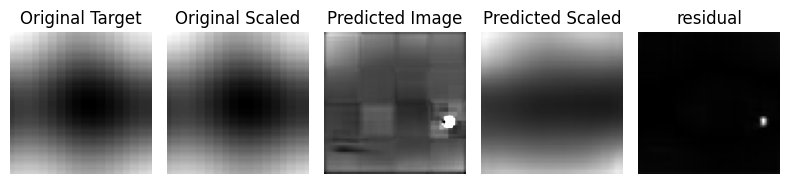

[TRAIN] epoch:  13 batch:  2 step:  150 loss:  0.031836509704589844 recon_detail loss:  (tensor(0.0032, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2170, device='mps:0'), tensor(69.3791, device='mps:0'))
BEFROE TRAIN


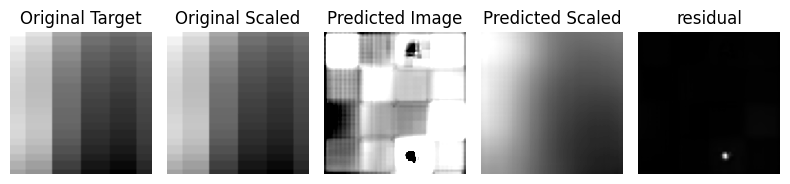

[TRAIN] epoch:  13 batch:  3 step:  200 loss:  0.04498717933893204 recon_detail loss:  (tensor(0.0045, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2464, device='mps:0'), tensor(63.9083, device='mps:0'))
BEFROE TRAIN


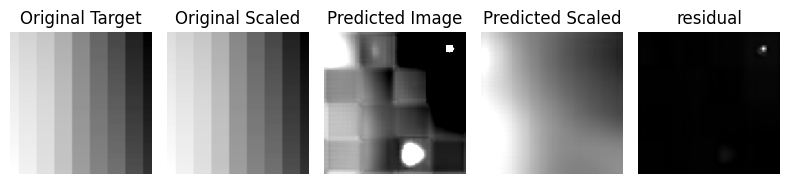

[TRAIN] epoch:  13 batch:  3 step:  250 loss:  0.03304671496152878 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2587, device='mps:0'), tensor(63.8744, device='mps:0'))
BEFROE TRAIN


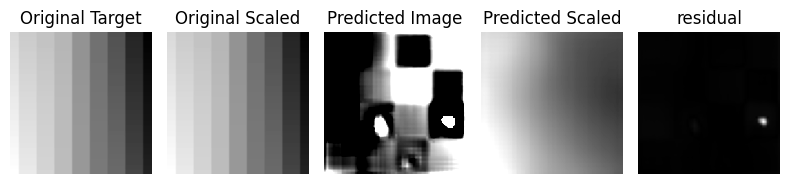

[TRAIN] epoch:  13 batch:  4 step:  300 loss:  0.026129567995667458 recon_detail loss:  (tensor(0.0026, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2590, device='mps:0'), tensor(63.7717, device='mps:0'))
BEFROE TRAIN


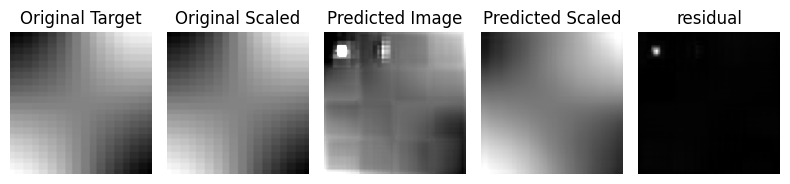

[TRAIN] epoch:  13 batch:  5 step:  350 loss:  0.04054863378405571 recon_detail loss:  (tensor(0.0041, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2580, device='mps:0'), tensor(60.0653, device='mps:0'))
BEFROE TRAIN


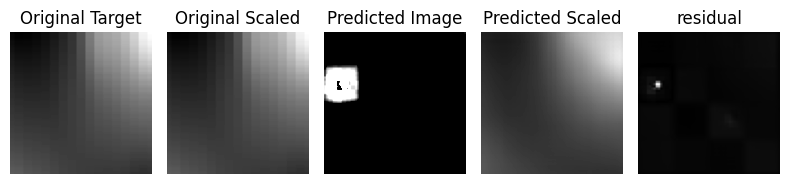

[VALID] epoch:  13 batch:  0 step:  20 loss:  0.028754716739058495 recon_detail loss:  (tensor(0.0029, device='mps:0'), tensor(0.2334, device='mps:0'), tensor(61.5269, device='mps:0'))


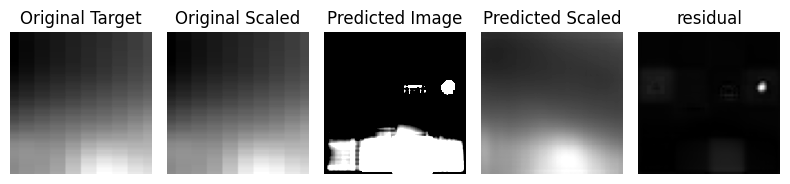

[VALID] epoch:  13 batch:  0 step:  40 loss:  0.029003743082284927 recon_detail loss:  (tensor(0.0029, device='mps:0'), tensor(0.2288, device='mps:0'), tensor(61.1038, device='mps:0'))


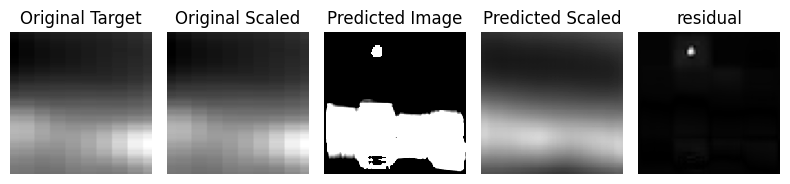

[VALID] epoch:  13 batch:  0 step:  60 loss:  0.02853875793516636 recon_detail loss:  (tensor(0.0029, device='mps:0'), tensor(0.2255, device='mps:0'), tensor(62.0982, device='mps:0'))


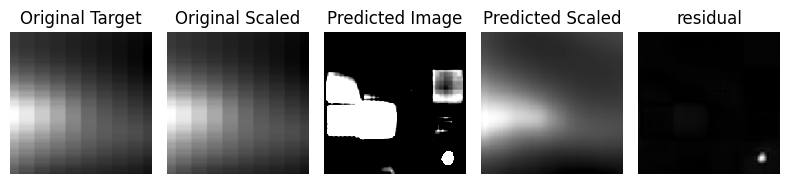

Epoch 14/1000, Train Loss: 3.324075e-02, Val Loss: 2.890762e-02
[TRAIN] epoch:  14 batch:  0 step:  50 loss:  0.027209371328353882 recon_detail loss:  (tensor(0.0027, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2278, device='mps:0'), tensor(65.7053, device='mps:0'))
BEFROE TRAIN


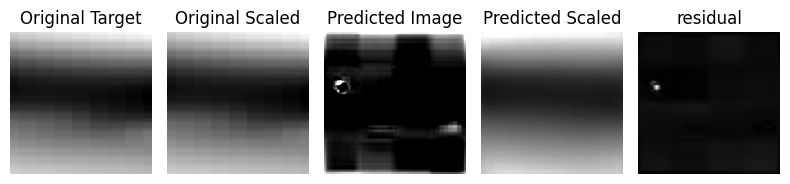

[TRAIN] epoch:  14 batch:  1 step:  100 loss:  0.01961582340300083 recon_detail loss:  (tensor(0.0020, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2646, device='mps:0'), tensor(63.5001, device='mps:0'))
BEFROE TRAIN


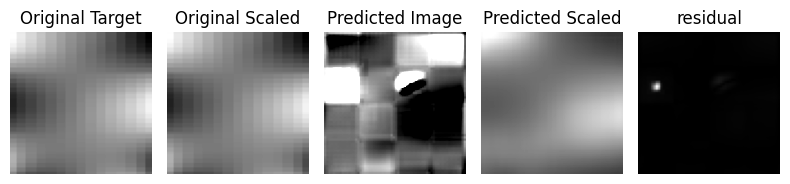

[TRAIN] epoch:  14 batch:  2 step:  150 loss:  0.026232581585645676 recon_detail loss:  (tensor(0.0026, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2298, device='mps:0'), tensor(63.2090, device='mps:0'))
BEFROE TRAIN


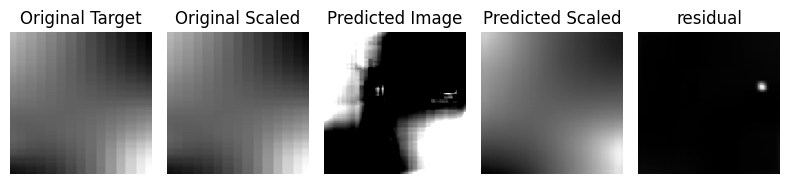

[TRAIN] epoch:  14 batch:  3 step:  200 loss:  0.025223586708307266 recon_detail loss:  (tensor(0.0025, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2109, device='mps:0'), tensor(65.2279, device='mps:0'))
BEFROE TRAIN


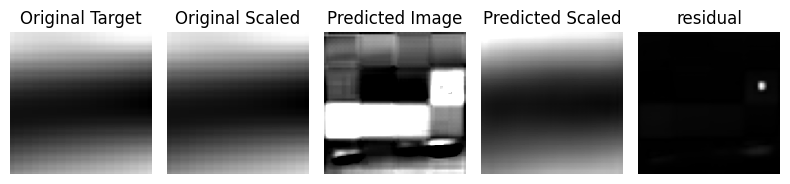

[TRAIN] epoch:  14 batch:  3 step:  250 loss:  0.028098586946725845 recon_detail loss:  (tensor(0.0028, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2115, device='mps:0'), tensor(66.2073, device='mps:0'))
BEFROE TRAIN


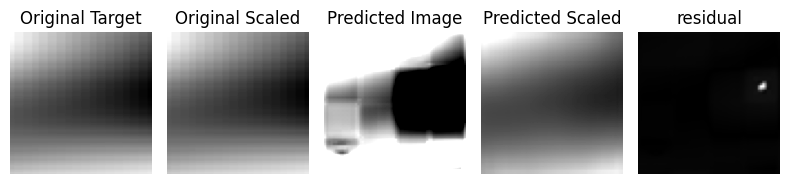

[TRAIN] epoch:  14 batch:  4 step:  300 loss:  0.036086417734622955 recon_detail loss:  (tensor(0.0036, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2276, device='mps:0'), tensor(62.1848, device='mps:0'))
BEFROE TRAIN


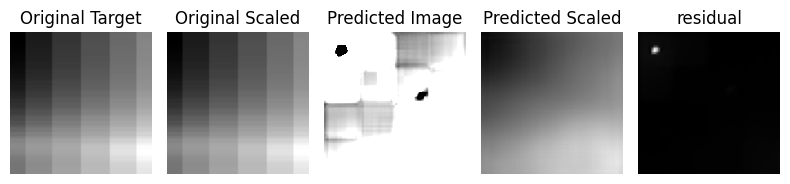

[TRAIN] epoch:  14 batch:  5 step:  350 loss:  0.05043407902121544 recon_detail loss:  (tensor(0.0050, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2708, device='mps:0'), tensor(68.3069, device='mps:0'))
BEFROE TRAIN


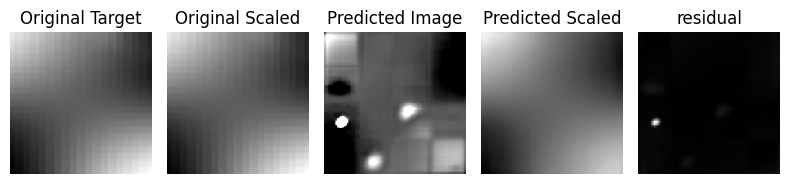

[VALID] epoch:  14 batch:  0 step:  20 loss:  0.029111016541719437 recon_detail loss:  (tensor(0.0029, device='mps:0'), tensor(0.2834, device='mps:0'), tensor(68.8202, device='mps:0'))


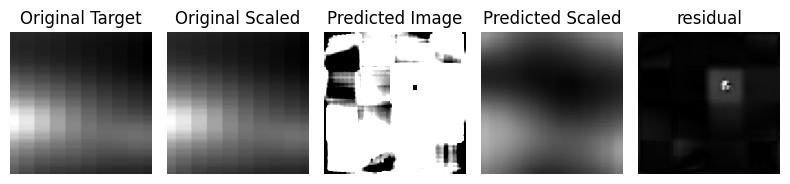

[VALID] epoch:  14 batch:  0 step:  40 loss:  0.028980830684304237 recon_detail loss:  (tensor(0.0029, device='mps:0'), tensor(0.2888, device='mps:0'), tensor(69.4870, device='mps:0'))


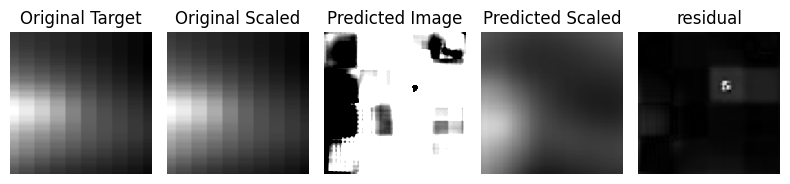

[VALID] epoch:  14 batch:  0 step:  60 loss:  0.02816448174417019 recon_detail loss:  (tensor(0.0028, device='mps:0'), tensor(0.2759, device='mps:0'), tensor(68.3192, device='mps:0'))


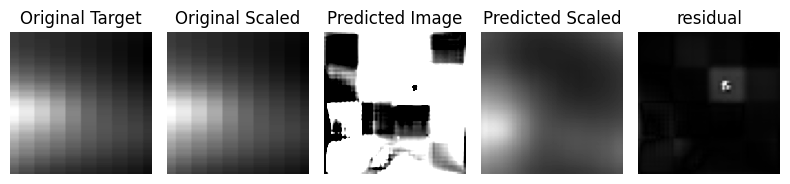

Epoch 15/1000, Train Loss: 3.254788e-02, Val Loss: 2.911468e-02
[TRAIN] epoch:  15 batch:  0 step:  50 loss:  0.0351836122572422 recon_detail loss:  (tensor(0.0035, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2336, device='mps:0'), tensor(62.2306, device='mps:0'))
BEFROE TRAIN


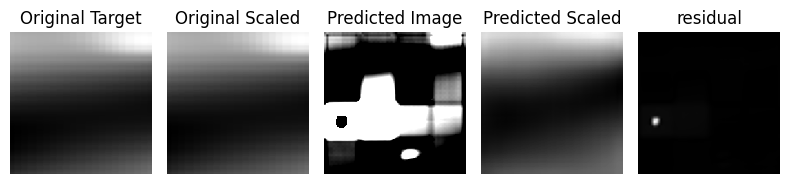

[TRAIN] epoch:  15 batch:  1 step:  100 loss:  0.025963615626096725 recon_detail loss:  (tensor(0.0026, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2421, device='mps:0'), tensor(60.0399, device='mps:0'))
BEFROE TRAIN


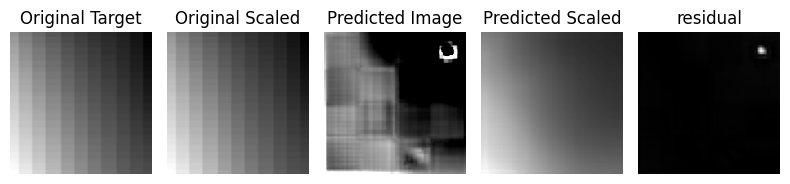

[TRAIN] epoch:  15 batch:  2 step:  150 loss:  0.032608747482299805 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2170, device='mps:0'), tensor(64.9489, device='mps:0'))
BEFROE TRAIN


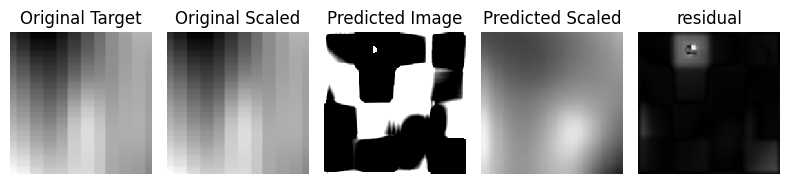

[TRAIN] epoch:  15 batch:  3 step:  200 loss:  0.03323010727763176 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2172, device='mps:0'), tensor(69.8356, device='mps:0'))
BEFROE TRAIN


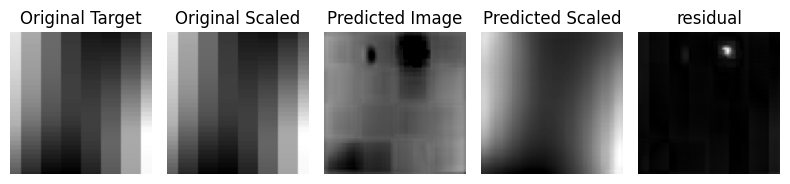

[TRAIN] epoch:  15 batch:  3 step:  250 loss:  0.027135375887155533 recon_detail loss:  (tensor(0.0027, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2192, device='mps:0'), tensor(70.7276, device='mps:0'))
BEFROE TRAIN


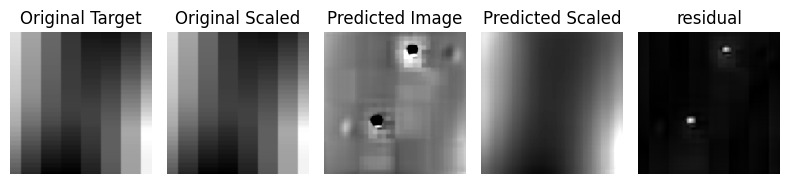

[TRAIN] epoch:  15 batch:  4 step:  300 loss:  0.027369674295186996 recon_detail loss:  (tensor(0.0027, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2270, device='mps:0'), tensor(65.0237, device='mps:0'))
BEFROE TRAIN


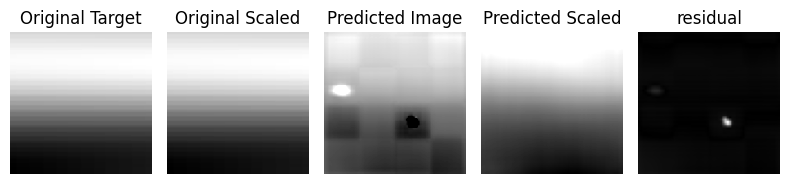

[TRAIN] epoch:  15 batch:  5 step:  350 loss:  0.04941696673631668 recon_detail loss:  (tensor(0.0049, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2811, device='mps:0'), tensor(64.5804, device='mps:0'))
BEFROE TRAIN


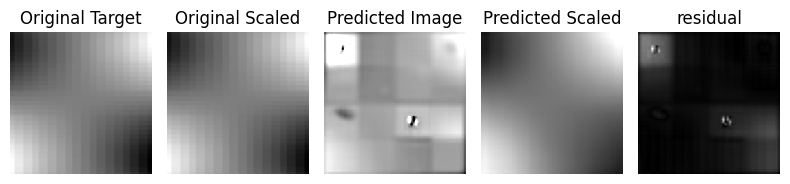

[VALID] epoch:  15 batch:  0 step:  20 loss:  0.027790546417236328 recon_detail loss:  (tensor(0.0028, device='mps:0'), tensor(0.2851, device='mps:0'), tensor(65.2910, device='mps:0'))


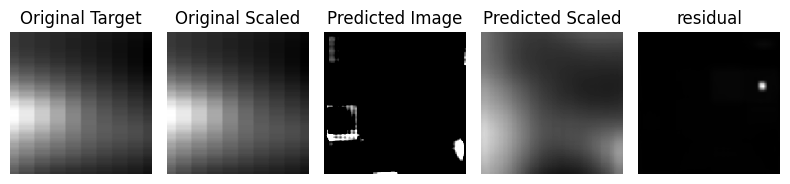

[VALID] epoch:  15 batch:  0 step:  40 loss:  0.025747254490852356 recon_detail loss:  (tensor(0.0026, device='mps:0'), tensor(0.2826, device='mps:0'), tensor(65.3051, device='mps:0'))


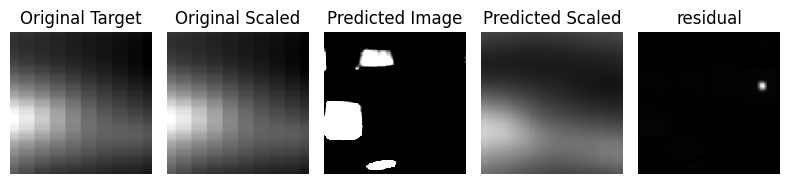

[VALID] epoch:  15 batch:  0 step:  60 loss:  0.02690778858959675 recon_detail loss:  (tensor(0.0027, device='mps:0'), tensor(0.2815, device='mps:0'), tensor(65.1882, device='mps:0'))


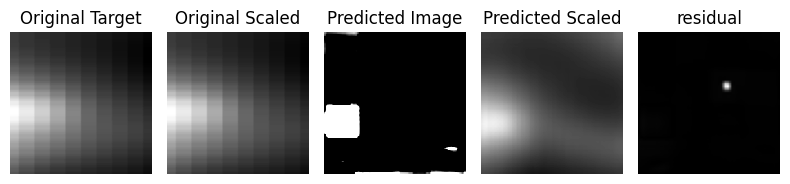

Epoch 16/1000, Train Loss: 3.224708e-02, Val Loss: 2.774349e-02
[TRAIN] epoch:  16 batch:  0 step:  50 loss:  0.028954578563570976 recon_detail loss:  (tensor(0.0029, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2186, device='mps:0'), tensor(61.3228, device='mps:0'))
BEFROE TRAIN


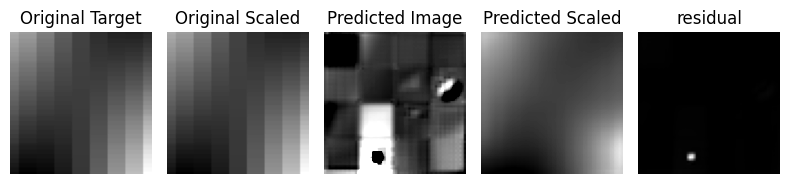

[TRAIN] epoch:  16 batch:  1 step:  100 loss:  0.03697504103183746 recon_detail loss:  (tensor(0.0037, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2570, device='mps:0'), tensor(62.4572, device='mps:0'))
BEFROE TRAIN


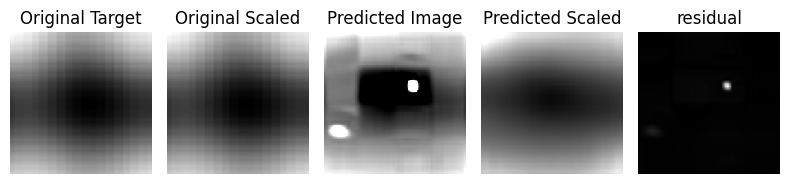

[TRAIN] epoch:  16 batch:  2 step:  150 loss:  0.02726186439394951 recon_detail loss:  (tensor(0.0027, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2220, device='mps:0'), tensor(67.7336, device='mps:0'))
BEFROE TRAIN


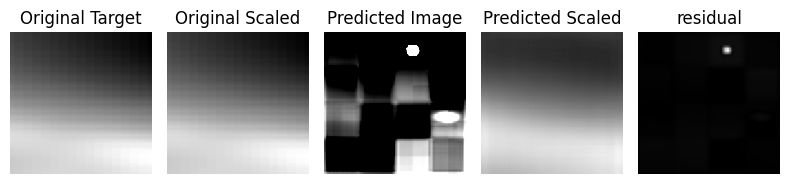

[TRAIN] epoch:  16 batch:  3 step:  200 loss:  0.033098138868808746 recon_detail loss:  (tensor(0.0033, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2356, device='mps:0'), tensor(61.6557, device='mps:0'))
BEFROE TRAIN


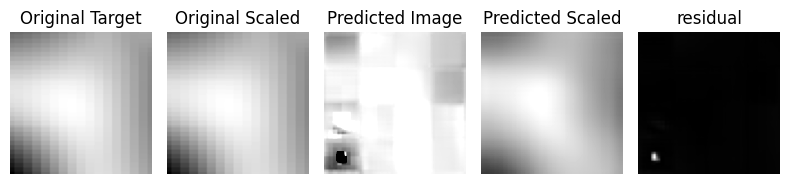

[TRAIN] epoch:  16 batch:  3 step:  250 loss:  0.029138144105672836 recon_detail loss:  (tensor(0.0029, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2379, device='mps:0'), tensor(61.9166, device='mps:0'))
BEFROE TRAIN


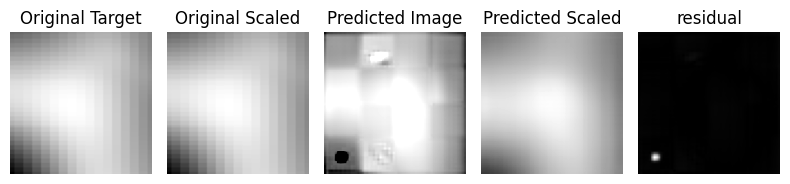

[TRAIN] epoch:  16 batch:  4 step:  300 loss:  0.029061000794172287 recon_detail loss:  (tensor(0.0029, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2394, device='mps:0'), tensor(65.0565, device='mps:0'))
BEFROE TRAIN


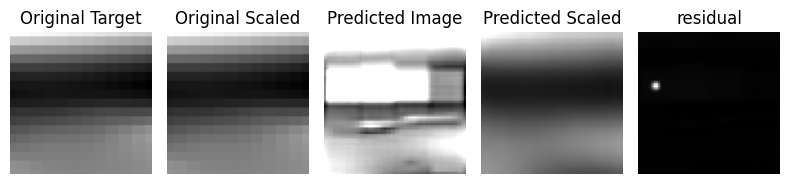

[TRAIN] epoch:  16 batch:  5 step:  350 loss:  0.029263170436024666 recon_detail loss:  (tensor(0.0029, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2180, device='mps:0'), tensor(67.8483, device='mps:0'))
BEFROE TRAIN


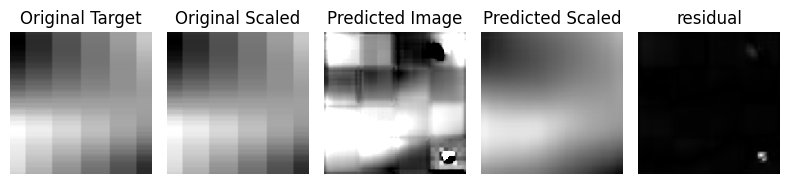

[VALID] epoch:  16 batch:  0 step:  20 loss:  0.025072814896702766 recon_detail loss:  (tensor(0.0025, device='mps:0'), tensor(0.2281, device='mps:0'), tensor(68.3028, device='mps:0'))


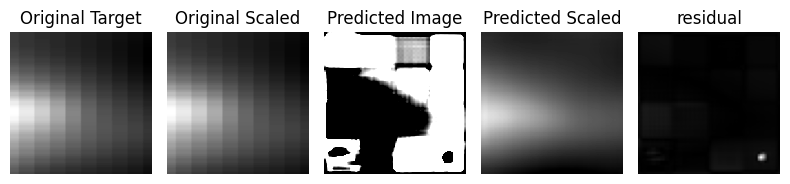

[VALID] epoch:  16 batch:  0 step:  40 loss:  0.024510493502020836 recon_detail loss:  (tensor(0.0025, device='mps:0'), tensor(0.2197, device='mps:0'), tensor(68.9388, device='mps:0'))


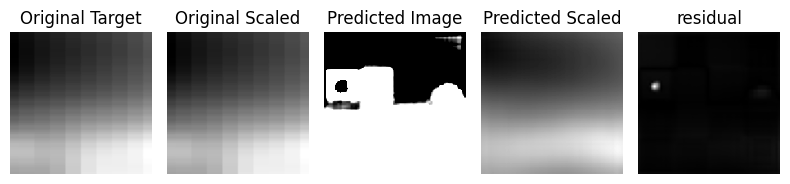

[VALID] epoch:  16 batch:  0 step:  60 loss:  0.023162703961133957 recon_detail loss:  (tensor(0.0023, device='mps:0'), tensor(0.2179, device='mps:0'), tensor(67.4533, device='mps:0'))


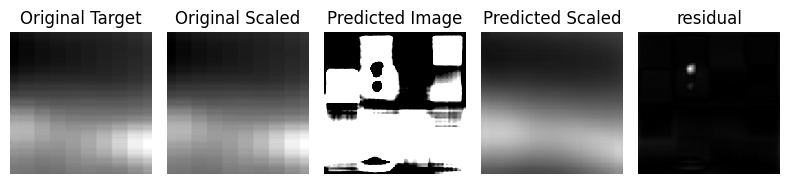

Epoch 17/1000, Train Loss: 3.061373e-02, Val Loss: 2.476974e-02
[TRAIN] epoch:  17 batch:  0 step:  50 loss:  0.030423792079091072 recon_detail loss:  (tensor(0.0030, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2377, device='mps:0'), tensor(60.1406, device='mps:0'))
BEFROE TRAIN


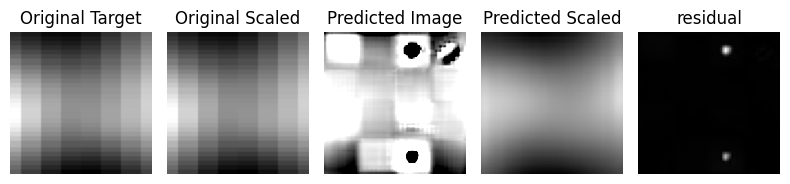

[TRAIN] epoch:  17 batch:  1 step:  100 loss:  0.04115033894777298 recon_detail loss:  (tensor(0.0041, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2607, device='mps:0'), tensor(64.0773, device='mps:0'))
BEFROE TRAIN


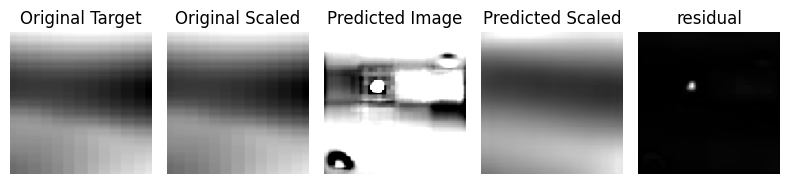

[TRAIN] epoch:  17 batch:  2 step:  150 loss:  0.0243704654276371 recon_detail loss:  (tensor(0.0024, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2359, device='mps:0'), tensor(64.9061, device='mps:0'))
BEFROE TRAIN


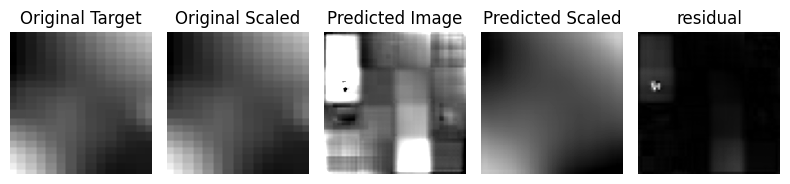

[TRAIN] epoch:  17 batch:  3 step:  200 loss:  0.023245355114340782 recon_detail loss:  (tensor(0.0023, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2288, device='mps:0'), tensor(58.1870, device='mps:0'))
BEFROE TRAIN


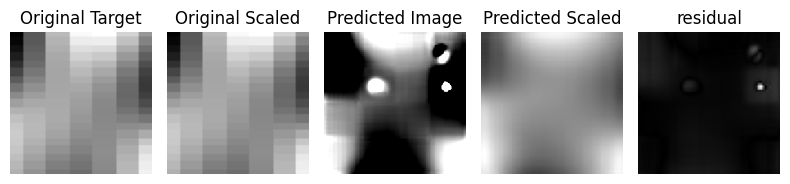

[TRAIN] epoch:  17 batch:  3 step:  250 loss:  0.022157002240419388 recon_detail loss:  (tensor(0.0022, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2275, device='mps:0'), tensor(57.5149, device='mps:0'))
BEFROE TRAIN


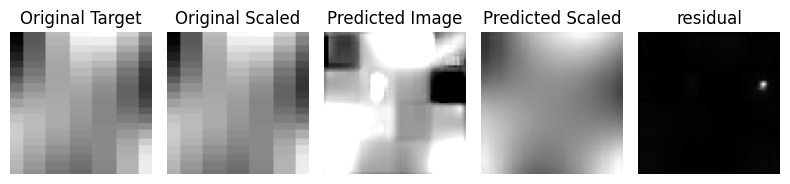

[TRAIN] epoch:  17 batch:  4 step:  300 loss:  0.03225507587194443 recon_detail loss:  (tensor(0.0032, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2235, device='mps:0'), tensor(64.6655, device='mps:0'))
BEFROE TRAIN


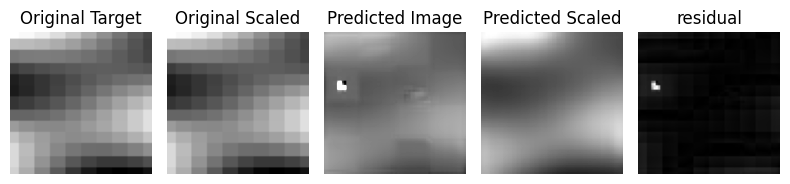

[TRAIN] epoch:  17 batch:  5 step:  350 loss:  0.021804746240377426 recon_detail loss:  (tensor(0.0022, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2058, device='mps:0'), tensor(66.9746, device='mps:0'))
BEFROE TRAIN


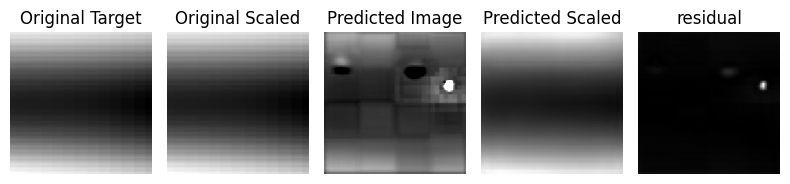

[VALID] epoch:  17 batch:  0 step:  20 loss:  0.030141668394207954 recon_detail loss:  (tensor(0.0030, device='mps:0'), tensor(0.2286, device='mps:0'), tensor(69.6289, device='mps:0'))


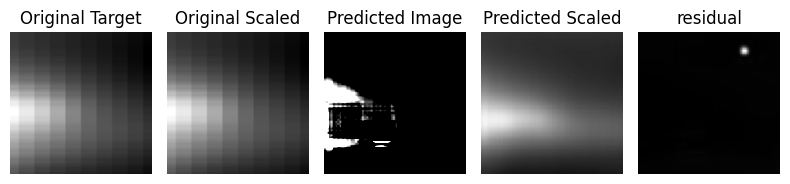

[VALID] epoch:  17 batch:  0 step:  40 loss:  0.025621559470891953 recon_detail loss:  (tensor(0.0026, device='mps:0'), tensor(0.2274, device='mps:0'), tensor(70.6956, device='mps:0'))


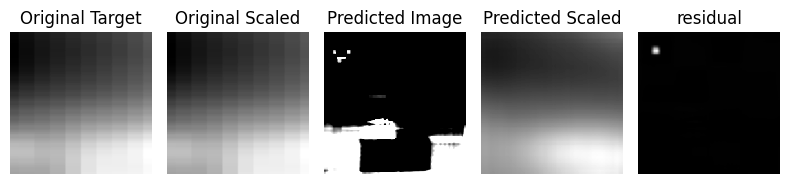

[VALID] epoch:  17 batch:  0 step:  60 loss:  0.026234880089759827 recon_detail loss:  (tensor(0.0026, device='mps:0'), tensor(0.2267, device='mps:0'), tensor(70.1910, device='mps:0'))


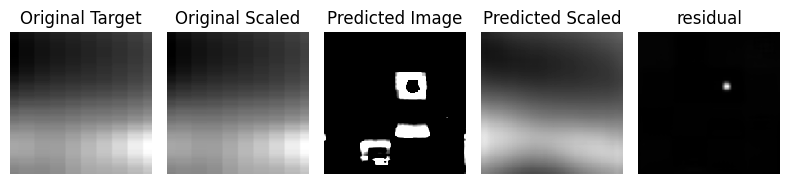

Epoch 18/1000, Train Loss: 2.957607e-02, Val Loss: 2.682152e-02
[TRAIN] epoch:  18 batch:  0 step:  50 loss:  0.020481450483202934 recon_detail loss:  (tensor(0.0020, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2114, device='mps:0'), tensor(58.4347, device='mps:0'))
BEFROE TRAIN


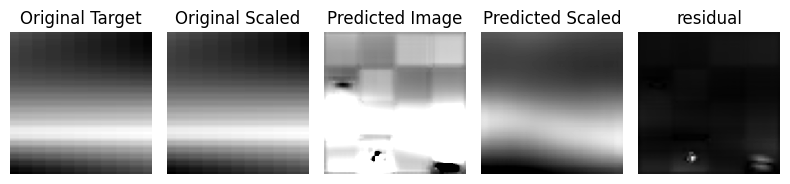

[TRAIN] epoch:  18 batch:  1 step:  100 loss:  0.0289015956223011 recon_detail loss:  (tensor(0.0029, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2503, device='mps:0'), tensor(60.2367, device='mps:0'))
BEFROE TRAIN


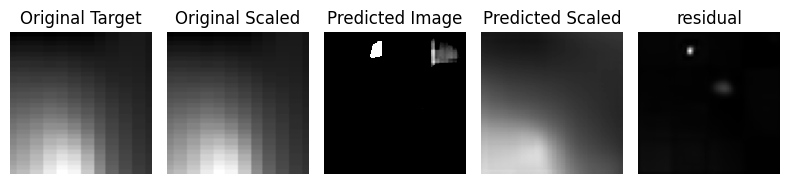

[TRAIN] epoch:  18 batch:  2 step:  150 loss:  0.013803353533148766 recon_detail loss:  (tensor(0.0014, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2650, device='mps:0'), tensor(63.1855, device='mps:0'))
BEFROE TRAIN


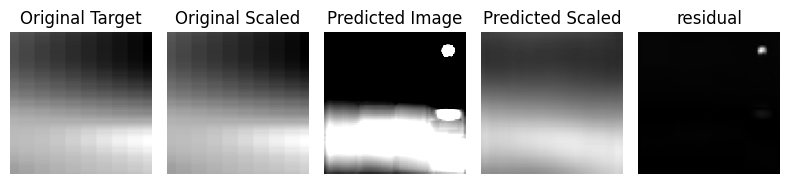

[TRAIN] epoch:  18 batch:  3 step:  200 loss:  0.058736611157655716 recon_detail loss:  (tensor(0.0059, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2637, device='mps:0'), tensor(64.0721, device='mps:0'))
BEFROE TRAIN


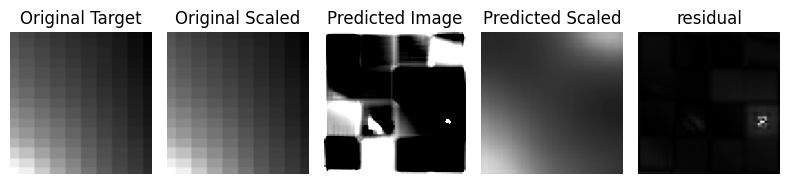

[TRAIN] epoch:  18 batch:  3 step:  250 loss:  0.05983153358101845 recon_detail loss:  (tensor(0.0060, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2587, device='mps:0'), tensor(64.2162, device='mps:0'))
BEFROE TRAIN


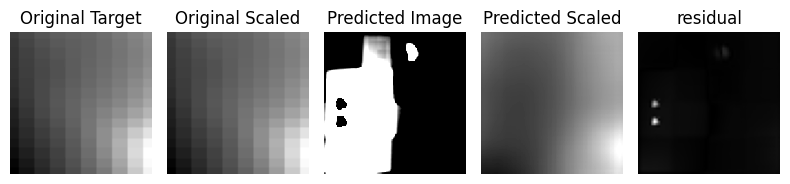

[TRAIN] epoch:  18 batch:  4 step:  300 loss:  0.0313028022646904 recon_detail loss:  (tensor(0.0031, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2230, device='mps:0'), tensor(70.1266, device='mps:0'))
BEFROE TRAIN


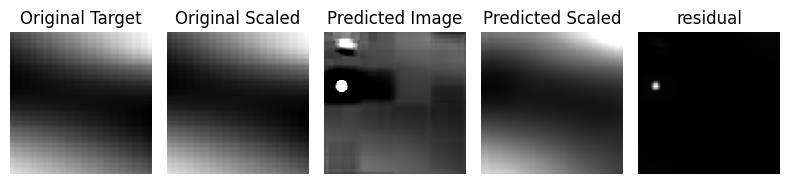

[TRAIN] epoch:  18 batch:  5 step:  350 loss:  0.026479076594114304 recon_detail loss:  (tensor(0.0026, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2302, device='mps:0'), tensor(63.4749, device='mps:0'))
BEFROE TRAIN


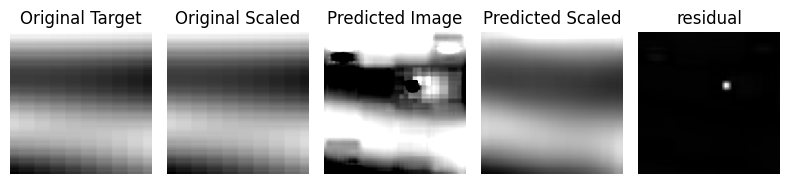

[VALID] epoch:  18 batch:  0 step:  20 loss:  0.024610867723822594 recon_detail loss:  (tensor(0.0025, device='mps:0'), tensor(0.2271, device='mps:0'), tensor(62.8814, device='mps:0'))


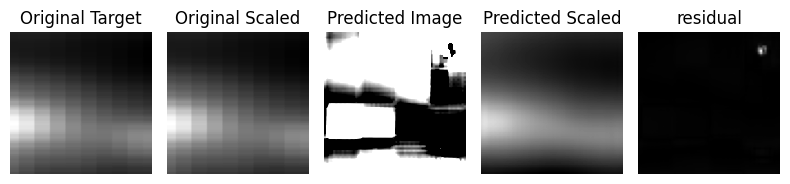

[VALID] epoch:  18 batch:  0 step:  40 loss:  0.025048602372407913 recon_detail loss:  (tensor(0.0025, device='mps:0'), tensor(0.2309, device='mps:0'), tensor(62.4082, device='mps:0'))


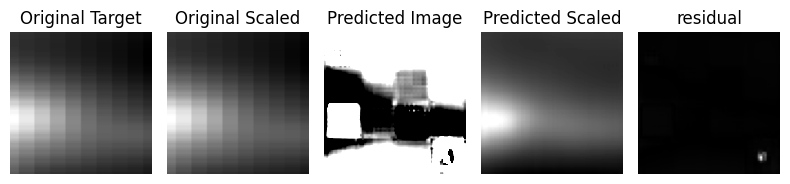

[VALID] epoch:  18 batch:  0 step:  60 loss:  0.025074856355786324 recon_detail loss:  (tensor(0.0025, device='mps:0'), tensor(0.2353, device='mps:0'), tensor(63.4619, device='mps:0'))


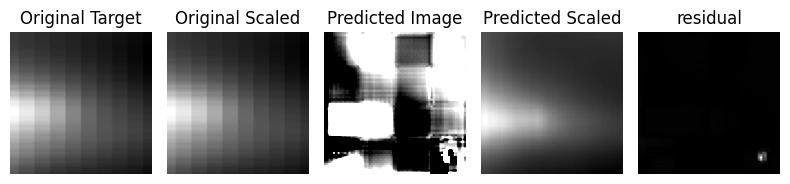

Epoch 19/1000, Train Loss: 2.876845e-02, Val Loss: 2.455747e-02
[TRAIN] epoch:  19 batch:  0 step:  50 loss:  0.01978897489607334 recon_detail loss:  (tensor(0.0020, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2363, device='mps:0'), tensor(61.3385, device='mps:0'))
BEFROE TRAIN


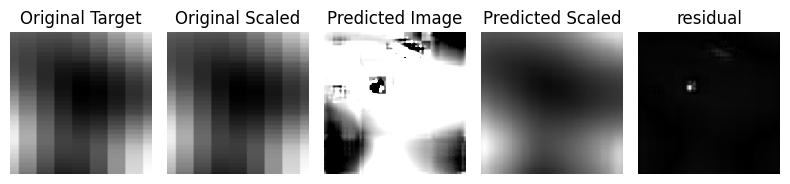

[TRAIN] epoch:  19 batch:  1 step:  100 loss:  0.051495056599378586 recon_detail loss:  (tensor(0.0051, device='mps:0', grad_fn=<AddBackward0>), tensor(0.2713, device='mps:0'), tensor(64.9647, device='mps:0'))
BEFROE TRAIN


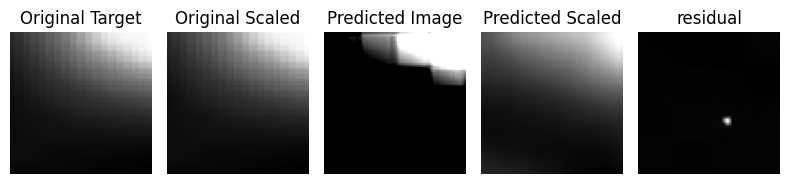

KeyboardInterrupt: 

In [1]:
import torch
import torch.nn.functional as F
from fem_dataset_to_image_full_mesh_diffusion import FemImageDataset as MeshDataset
from fem_model import ScalingVAE5
import json
from torch.utils.data import DataLoader
from utils import EarlyStopping
import gc
import numpy as np
import matplotlib.pyplot as plt


early_stopping = EarlyStopping(
    patience=5,     # FEM/GNN은 15~30 권장
    min_delta=1e-5,  # loss 스케일에 맞게
    mode="min"
)
def collate_flatten(batch): 
    images, conds = [], [] 
    batch_size=len(batch) 
    step_num_in_batch=len(batch[0]["image"]) 
    idxs=[] 
    for i in range(batch_size): 
        idx = torch.randperm(len(batch[0]["image"])) 
        idxs.append(idx) 
        # print(batch[i]['min_max'])
    idxs=np.array(idxs).T 

    for i in range(step_num_in_batch): 
        batch_images=[] 
        batch_conds=[] 
        for b_i,b in enumerate(batch): 
            id=idxs[i][b_i] 
            batch_images.append(b['image'][id]) 
            batch_conds.append(b['cond'][id]) 
        images.append(batch_images) 
        conds.append(batch_conds) 
    return { "image": images, "cond": conds, }

def draw(data1,data1_1,data2,data3,model_param): 
    
    plt.figure(figsize=(8, 4)) 
    plt.subplot(1, 5, 1) 
    plt.imshow(data1.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max()) 
    plt.title("Original Target") 
    plt.axis("off")
    plt.subplot(1, 5, 2) 
    plt.imshow(data1_1.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max()) 
    plt.title("Original Scaled") 
    plt.axis("off") 
    plt.subplot(1, 5, 3) 
    plt.imshow(data2.cpu().detach().numpy(), cmap="gray",vmin=data1.cpu().detach().numpy().min(),vmax=data1.cpu().detach().numpy().max())
    plt.title("Predicted Image") 
    plt.axis("off") 
    plt.subplot(1, 5, 4) 
    plt.imshow(data3.cpu().detach().numpy(), cmap="gray",vmin=data1_1.cpu().detach().numpy().min(),vmax=data1_1.cpu().detach().numpy().max())
    plt.title("Predicted Scaled") 
    plt.axis("off")
    plt.subplot(1, 5, 5) 
    plt.imshow(np.abs(data1.cpu().detach().numpy()-data2.cpu().detach().numpy()), cmap="gray")
    plt.title("residual") 
    plt.axis("off")
    plt.tight_layout() 
    plt.show()

def kl_divergence_gaussian(mu, logvar, clamp=(-0.3, 0.3)):
    """
    KL( N(mu, var) || N(0, I) )
    Supports mu/logvar with shape:
      [B, Z] or [B, C, H, W] or [B, ...]
    """
    if clamp is not None:
        logvar = torch.clamp(logvar, min=clamp[0], max=clamp[1])

    # flatten all non-batch dimensions
    mu = mu.view(mu.size(0), -1)
    logvar = logvar.view(logvar.size(0), -1)

    kl = 0.5 * torch.sum(
        torch.exp(logvar) + mu**2 - 1.0 - logvar,
        dim=1
    )

    return kl.mean()

def charbonnier_loss(pred: torch.Tensor,
                     target: torch.Tensor,
                     eps: float = 1e-8,
                     reduction: str = "mean") -> torch.Tensor:
    """
    Charbonnier loss (a smooth L1 / pseudo-Huber variant):
        L = sqrt((pred - target)^2 + eps^2)

    Args:
        pred, target: same shape tensors
        eps: smoothing term (bigger -> more L1-like near 0)
        reduction: "mean" | "sum" | "none"

    Returns:
        loss tensor (scalar if reduced)
    """
    if pred.shape != target.shape:
        raise ValueError(f"Shape mismatch: pred{pred.shape} vs target{target.shape}")

    diff = pred - target
    loss = torch.sqrt(diff * diff + eps * eps)

    if reduction == "mean":
        return loss.mean()
    if reduction == "sum":
        return loss.sum()
    if reduction == "none":
        return loss
    raise ValueError("reduction must be one of {'mean','sum','none'}")




def GradientDifferenceLossCharbonnier( pred, target):
    grad_pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    grad_target_x = target[:, :, :, 1:] - target[:, :, :, :-1]

    grad_pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    grad_target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    return (
        charbonnier_loss(grad_pred_x, grad_target_x) +
        charbonnier_loss(grad_pred_y, grad_target_y)
    )

def cvae_loss(target_x_norm,target,scaled_x_hat, x_hat,mean,std, mu, logvar,epoch, beta=1e-3): 
    recon= charbonnier_loss(target, x_hat)
    recon_2 = GradientDifferenceLossCharbonnier(target,x_hat)
    recon_detail = charbonnier_loss(target_x_norm, scaled_x_hat)
    recon_detail_2 = GradientDifferenceLossCharbonnier(target_x_norm,scaled_x_hat)
    recon_sum=0.8*recon +0.2*recon_2
    recon_detail_sum=0.8*recon_detail +0.2*recon_detail_2
    
    kl = kl_divergence_gaussian(mu, logvar)
    #return (0.8-0.4*epoch/100)*recon_detail +0.05*recon_detail_2+0.1*latent_mean+(0.1+0.4*epoch/100)*latent_logvar+ beta * kl, (recon_detail ,latent_mean,latent_logvar, kl)
    scale=10
    return scale*recon_sum  , (recon_sum,recon_detail_sum, kl)

def draw_latent(z): 

    z = z.view(z.size(0), -1) 
    plt.figure(figsize=(8, 4)) 
    plt.hist(z.flatten().detach().cpu(), bins=100) 
    plt.title("Image 1") 
    plt.show()

def train_one_epoch(model, loader, device, opt, model_param,epoch): 
    model.train() 
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            opt.zero_grad() 
            loss.backward() 
            opt.step() 
            total += float(loss.item())
            count+=1 
            if count % 50 == 0: 
                print('[TRAIN] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                print('BEFROE TRAIN')
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)
@torch.no_grad()
def eval_one_epoch(model, loader, device,  model_param,epoch):
    model.eval()
    total = 0.0 
    count=0 
    beta_target=1e-3
    warmup_epochs=10 
    warm = min(1.0, (epoch + 1) / max(1, warmup_epochs)) 
    beta = beta_target * warm 
    for i, batch in enumerate(loader): 
        imags=batch['image'] 
        conds=batch['cond'] 
        for b in range(len(imags)): 
            s_batch = {'image':torch.stack(imags[b]).to(device),'cond':torch.Tensor(np.array(conds[b])).to(device)} 
            mean = s_batch['image'].mean(dim=(1,2,3), keepdim=True).detach() 
            std = s_batch['image'].std(dim=(1,2,3), keepdim=True).detach() 
            x_norm=(s_batch['image']-mean)/std 
            std=torch.log(std**2+1e-12)
            scaled_image,image, mu, logvar, z= model(s_batch['image']) 
            loss, parts = cvae_loss(x_norm,s_batch['image'], scaled_image,image,mean,std,mu, logvar,epoch, beta=beta) 
            total += float(loss.item())
            count+=1 
            if count % 20 == 0: 
                print('[VALID] epoch: ',epoch,'batch: ',i,'step: ',count,'loss: ',float(loss.item()),'recon_detail loss: ', parts) 
                origin_image=torch.stack(imags[b])[0,:][(model_param['in_channels']-1)//2] 
                pred_image=image[0,:][(model_param['in_channels']-1)//2].cpu()
                origin_image_norm=x_norm[0,:][(model_param['in_channels']-1)//2].cpu()
                draw(origin_image,origin_image_norm,pred_image,scaled_image[0,:][(model_param['in_channels']-1)//2].cpu(),model_param) 
        del batch 
        gc.collect() 
    return total / max(1, count)

def main():
    root = "./data"
    if torch.cuda.is_available() :
        device='cuda'
    elif torch.backends.mps.is_available() :
        device='mps'
    else :
        device='cpu'

    model_param={ 'in_channels':3, 
                'out_channels':3,
                'GRID':64,
                'loss_scale':1.0,
                'learning_rate':1e-3,
                'num_epochs':1000,
                'base':128,
                'latent_dim':64,
                'batch_size':128,
                'depth':4 } 
    
    train_ds = MeshDataset(root_dir=root,type='train',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 
    val_ds= MeshDataset(root_dir=root,type='valid',GRID=model_param['GRID'],in_channels=model_param['in_channels']) 

    train_loader = DataLoader(train_ds, batch_size=model_param['batch_size'], shuffle=True, collate_fn=collate_flatten) 
    val_loader = DataLoader(val_ds, batch_size=model_param['batch_size'], shuffle=False, collate_fn=collate_flatten) 
    example = train_ds[0] 
    model_param['cond_dim']=len(example['cond'][0]) 
    model_param['dataset_scale_info']=train_ds.scale_info 

    model = ScalingVAE5( in_channels=model_param['in_channels'], 
                latent_dim=model_param['latent_dim'], 
                base=model_param['base'],
                depth=model_param['depth'] ).to(device)
    ckpt = torch.load("mesh_invariant_diffustion_vae4_3_early_epoch010.pt", map_location=device)
    model.load_state_dict(ckpt)
    model.to(device)
    for p in model.parameters():
        p.requires_grad = False
    for p in model.decoder.avg_layers.parameters():
        p.requires_grad = True
    for p in model.decoder.std_layers.parameters():
        p.requires_grad = True

    optimizer = torch.optim.Adam(model.parameters(), lr=model_param['learning_rate'], weight_decay=1e-6)
    loss_dict={}
    for epoch in range(model_param['num_epochs']):        
        epoch=epoch+11
        train_loss = train_one_epoch(model, train_loader, device, optimizer,model_param,epoch)
        val_loss = eval_one_epoch(model, val_loader, device,model_param,epoch)
        loss_dict[epoch] = {'train_loss':train_loss, 'val_loss':val_loss}   
        print(f"Epoch {epoch+1}/{model_param['num_epochs']}, Train Loss: {train_loss:.6e}, Val Loss: {val_loss:.6e}")  
        improved = early_stopping.step(val_loss)
        with open(f"loss_history_diffustion_vae4_3.json", "w", encoding="utf-8") as f:
            json.dump(loss_dict, f, indent=2)
        if improved:
            best_val = val_loss
            # print(eval_one_epoch_sample_mse(model, val_loader, device, sched))
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_early_epoch{str(epoch).zfill(3)}.pt")  # best만 저장

            with open(f"model_param_diffustion_vae4_3_early.json", "w", encoding="utf-8") as f:
                json.dump(model_param, f, indent=2)
        if early_stopping.should_stop:
            print(
                f"\n Early stopping at epoch {epoch} "
                f"(best val = {best_val:.6e})"
            )
            break
        if epoch%5==0:
            torch.save(model.state_dict(), f"mesh_invariant_diffustion_vae4_3_epoch{str(epoch).zfill(3)}.pt")
    torch.save(model.state_dict(), "mesh_invariant_diffustion_vae4_3.pt")
    with open(f"model_param_diffusion_vae4_3.json", "w", encoding="utf-8") as f:
        json.dump(model_param, f, indent=2) 

if __name__ == "__main__":
    main()